In [31]:
from scenedetect import detect, ContentDetector, split_video_ffmpeg, SceneManager, AdaptiveDetector, ThresholdDetector, HashDetector, HistogramDetector, StatsManager, save_images, open_video
video_path = '/Users/spectatr/Downloads/soccernet_data/england_epl/2014-2015/2015-02-21 - 18-00 Chelsea 1 - 1 Burnley/2_720p.mkv'
video = open_video(video_path)
scene_manager = SceneManager(stats_manager=StatsManager())
# scene_manager.add_detector(ContentDetector()) #Hash Detector
scene_manager.add_detector(AdaptiveDetector())
scene_manager.detect_scenes(video=video)
scene_list = scene_manager.get_scene_list()
scene_manager.stats_manager.save_to_csv(csv_file='/Users/spectatr/Downloads/general_scripts/model_improvement_experiments/threshold_stats.csv')

# scene_list = detect(video_path, AdaptiveDetector()) #thresholod inside content detection: Content got 249 frames.
""" In above, we can add show_progress=True"""

print(f"Lenght of scene list is {len(scene_list)} and scene_list is {scene_list}") 
#save-images command:save an image of the first and last frame of each detected scene via the
save_images(scene_list, open_video(video_path), image_name_template='$VIDEO_NAME-Scene-$SCENE_NUMBER-$IMAGE_NUMBER', output_dir='./save_images') # Error with this: image_extension='.jpg'

Lenght of scene list is 152 and scene_list is [(00:00:00.000 [frame=0, fps=25.000], 00:00:33.720 [frame=843, fps=25.000]), (00:00:33.720 [frame=843, fps=25.000], 00:00:37.600 [frame=940, fps=25.000]), (00:00:37.600 [frame=940, fps=25.000], 00:00:43.680 [frame=1092, fps=25.000]), (00:00:43.680 [frame=1092, fps=25.000], 00:01:06.720 [frame=1668, fps=25.000]), (00:01:06.720 [frame=1668, fps=25.000], 00:01:13.680 [frame=1842, fps=25.000]), (00:01:13.680 [frame=1842, fps=25.000], 00:01:43.520 [frame=2588, fps=25.000]), (00:01:43.520 [frame=2588, fps=25.000], 00:01:48.960 [frame=2724, fps=25.000]), (00:01:48.960 [frame=2724, fps=25.000], 00:02:00.840 [frame=3021, fps=25.000]), (00:02:00.840 [frame=3021, fps=25.000], 00:02:05.640 [frame=3141, fps=25.000]), (00:02:05.640 [frame=3141, fps=25.000], 00:02:10.160 [frame=3254, fps=25.000]), (00:02:10.160 [frame=3254, fps=25.000], 00:02:16.640 [frame=3416, fps=25.000]), (00:02:16.640 [frame=3416, fps=25.000], 00:02:51.600 [frame=4290, fps=25.000]), 

{0: ['2_720p-Scene-001-01.jpg',
  '2_720p-Scene-001-02.jpg',
  '2_720p-Scene-001-03.jpg'],
 1: ['2_720p-Scene-002-01.jpg',
  '2_720p-Scene-002-02.jpg',
  '2_720p-Scene-002-03.jpg'],
 2: ['2_720p-Scene-003-01.jpg',
  '2_720p-Scene-003-02.jpg',
  '2_720p-Scene-003-03.jpg'],
 3: ['2_720p-Scene-004-01.jpg',
  '2_720p-Scene-004-02.jpg',
  '2_720p-Scene-004-03.jpg'],
 4: ['2_720p-Scene-005-01.jpg',
  '2_720p-Scene-005-02.jpg',
  '2_720p-Scene-005-03.jpg'],
 5: ['2_720p-Scene-006-01.jpg',
  '2_720p-Scene-006-02.jpg',
  '2_720p-Scene-006-03.jpg'],
 6: ['2_720p-Scene-007-01.jpg',
  '2_720p-Scene-007-02.jpg',
  '2_720p-Scene-007-03.jpg'],
 7: ['2_720p-Scene-008-01.jpg',
  '2_720p-Scene-008-02.jpg',
  '2_720p-Scene-008-03.jpg'],
 8: ['2_720p-Scene-009-01.jpg',
  '2_720p-Scene-009-02.jpg',
  '2_720p-Scene-009-03.jpg'],
 9: ['2_720p-Scene-010-01.jpg',
  '2_720p-Scene-010-02.jpg',
  '2_720p-Scene-010-03.jpg'],
 10: ['2_720p-Scene-011-01.jpg',
  '2_720p-Scene-011-02.jpg',
  '2_720p-Scene-011-03.jpg']

In [ ]:
# AdaptiveDetector(
#             adaptive_threshold=2.5,  # More sensitive
#             min_scene_len=10,
#             window_width=3,  # Larger window for camera movement
#             min_content_val=12.0  # Lower minimum for subtle changes
#         )

# ContentDetector(
#             threshold=30.0,  # Slightly higher for sports
#             min_scene_len=10,  # Shorter minimum for fast action
#             weights=ContentDetector.Components(
#                 delta_hue=0.5,      # Reduced - grass/field colors are consistent
#                 delta_sat=0.7,      # Moderate - some variation in colors
#                 delta_lum=1.2,      # Increased - lighting changes important
#                 delta_edges=0.3     # Some edge detection for movement
#             )

In [46]:
import os
import cv2
import numpy as np
import pandas as pd
from typing import List, Tuple, Optional
# from utils.log_utils import logger

class FastCameraViewDetector:
    """
    Optimized camera view detector that combines speed optimizations
    with your existing logic for football footage.
    """
    
    def __init__(self, 
                 threshold: float = 20,
                 min_scene_len: int = 15,
                 hash_size: int = 8,  # Reduced from 16 for speed
                 method: str = 'content'):  # 'content', 'hash', or 'histogram'
        self.threshold = threshold
        self.min_scene_len = min_scene_len
        self.hash_size = hash_size
        self.method = method
        
        # Pre-allocate arrays for speed
        self.prev_frame_data = None
        self.frame_scores = []
        self.frame_pairs = []
        
    def _calculate_content_score(self, frame1: np.ndarray, frame2: np.ndarray) -> float:
        """
        Fast content-based similarity using HSV differences (like PySceneDetect ContentDetector).
        Much faster than perceptual hashing.
        """
        # Convert to HSV (more efficient than multiple conversions)
        hsv1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2HSV)
        hsv2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2HSV)
        
        # Calculate mean absolute difference for each channel
        h_diff = np.mean(np.abs(hsv1[:,:,0].astype(np.float32) - hsv2[:,:,0].astype(np.float32)))
        s_diff = np.mean(np.abs(hsv1[:,:,1].astype(np.float32) - hsv2[:,:,1].astype(np.float32)))
        v_diff = np.mean(np.abs(hsv1[:,:,2].astype(np.float32) - hsv2[:,:,2].astype(np.float32)))
        
        # Weighted combination (optimized for football - emphasize brightness changes)
        score = (h_diff * 0.5 + s_diff * 0.7 + v_diff * 1.2) / 2.4
        return score
    
    def _calculate_fast_hash_score(self, frame1: np.ndarray, frame2: np.ndarray) -> float:
        """
        Simplified hash-based similarity (much faster than imagehash.phash).
        """
        # Convert to grayscale and resize (smaller = faster)
        gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
        gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
        
        # Resize to small size for speed
        small1 = cv2.resize(gray1, (self.hash_size, self.hash_size), interpolation=cv2.INTER_AREA)
        small2 = cv2.resize(gray2, (self.hash_size, self.hash_size), interpolation=cv2.INTER_AREA)
        
        # Simple difference calculation
        diff = np.mean(np.abs(small1.astype(np.float32) - small2.astype(np.float32)))
        return diff
    
    def _calculate_histogram_score(self, frame1: np.ndarray, frame2: np.ndarray) -> float:
        """
        Fast histogram-based similarity using Y channel.
        """
        # Convert to YUV and extract Y channel
        yuv1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2YUV)
        yuv2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2YUV)
        
        # Calculate histograms (reduced bins for speed)
        hist1 = cv2.calcHist([yuv1], [0], None, [64], [0, 256])  # Reduced from 256 bins
        hist2 = cv2.calcHist([yuv2], [0], None, [64], [0, 256])
        
        # Normalize and compare
        cv2.normalize(hist1, hist1)
        cv2.normalize(hist2, hist2)
        
        # Return inverse correlation (higher = more different)
        correlation = cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)
        return (1.0 - correlation) * 100  # Scale to match your threshold range
    
    def detect_scene_changes(self, video_path: str) -> Tuple[List[float], List[str], int]:
        """
        Fast single-pass scene change detection.
        """
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise ValueError(f"Could not open video: {video_path}")
        
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        # Pre-allocate lists for better performance
        scores = []
        pairs = []
        
        # Read first frame
        ret, prev_frame = cap.read()
        if not ret:
            raise ValueError("Could not read first frame")
        
        # Resize frames for faster processing (optional)
        height, width = prev_frame.shape[:2]
        if width > 640:  # Only resize if necessary
            scale = 640.0 / width
            new_width = int(width * scale)
            new_height = int(height * scale)
            prev_frame = cv2.resize(prev_frame, (new_width, new_height))
        
        frame_idx = 1
        
        while True:
            ret, current_frame = cap.read()
            if not ret:
                break
            
            # Resize current frame to match previous
            if width > 640:
                current_frame = cv2.resize(current_frame, (new_width, new_height))
            
            # Calculate similarity score based on method
            if self.method == 'content':
                score = self._calculate_content_score(prev_frame, current_frame)
            elif self.method == 'hash':
                score = self._calculate_fast_hash_score(prev_frame, current_frame)
            elif self.method == 'histogram':
                score = self._calculate_histogram_score(prev_frame, current_frame)
            else:
                raise ValueError(f"Unknown method: {self.method}")
            
            scores.append(score)
            pairs.append(f"{frame_idx-1}-{frame_idx}")
            
            # Move to next frame
            prev_frame = current_frame
            frame_idx += 1
            
            # Progress logging every 1000 frames
            if frame_idx % 1000 == 0:
                print(f"Processed {frame_idx}/{frame_count} frames")
        
        cap.release()
        return scores, pairs, frame_count
    
    def filter_scene_changes(self, scores: List[float], pairs: List[str]) -> List[dict]:
        """
        Fast filtering using numpy operations instead of loops.
        """
        scores_array = np.array(scores)
        
        # Find frames above threshold
        above_threshold = scores_array >= self.threshold
        threshold_indices = np.where(above_threshold)[0]
        
        results = []
        
        # Add header
        results.append({
            'Frame Pair': '------',
            'left_avg': '-----',
            'Similarity Score': '-------',
            'right_avg': '-------'
        })
        
        # Process each detection
        for idx in threshold_indices:
            # Get surrounding context (vectorized)
            start_idx = max(0, idx - 3)
            end_idx = min(len(scores), idx + 4)
            
            # Get previous and next scores (excluding current)
            prev_scores = scores_array[start_idx:idx]
            next_scores = scores_array[idx+1:end_idx]
            
            # Filter out zeros
            prev_scores = prev_scores[prev_scores > 0]
            next_scores = next_scores[next_scores > 0]
            
            if len(prev_scores) == 0 or len(next_scores) == 0:
                continue
            
            avg_prev = np.mean(prev_scores)
            avg_next = np.mean(next_scores)
            current_score = scores_array[idx]
            
            # Apply your filtering logic
            if avg_prev >= current_score / 3 and avg_next >= current_score / 3:
                continue
            
            results.append({
                'Frame Pair': pairs[idx],
                'left_avg': avg_prev,
                'Similarity Score': current_score,
                'right_avg': avg_next
            })
        
        return results
    
    def fast_duplicate_removal(self, results: List[dict], video_path: str) -> List[dict]:
        """
        Optimized duplicate removal using batch processing.
        """
        if len(results) <= 1:
            return results
        
        # Extract frame pairs (skip header)
        frame_pairs = [r['Frame Pair'] for r in results[1:]]
        if not frame_pairs:
            return results
        
        # Extract all frame numbers we need to check
        frame_numbers = []
        pair_mapping = {}
        
        for i, pair in enumerate(frame_pairs):
            start, end = map(int, pair.split('-'))
            frame_numbers.extend([start, end])
            pair_mapping[(start, end)] = i + 1  # +1 to account for header
        
        # Remove duplicates and sort
        unique_frames = sorted(set(frame_numbers))
        
        # Read required frames in batch
        cap = cv2.VideoCapture(video_path)
        frame_data = {}
        
        for frame_num in unique_frames:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
            ret, frame = cap.read()
            if ret:
                # Convert to HSV and calculate histogram
                hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
                hist = cv2.calcHist([hsv], [0, 1, 2], None, [50, 50, 50], [0, 256, 0, 256, 0, 256])
                cv2.normalize(hist, hist)
                frame_data[frame_num] = hist
        
        cap.release()
        
        # Compare histograms for each pair
        rows_to_keep = [0]  # Keep header
        
        for pair in frame_pairs:
            start, end = map(int, pair.split('-'))
            
            if start in frame_data and end in frame_data:
                similarity = cv2.compareHist(frame_data[start], frame_data[end], cv2.HISTCMP_CORREL)
                
                if similarity <= 0.90:  # Keep if not too similar
                    rows_to_keep.append(pair_mapping[(start, end)])
            else:
                # Keep if we couldn't read the frames
                rows_to_keep.append(pair_mapping[(start, end)])
        
        # Return filtered results
        return [results[i] for i in rows_to_keep]

def fast_camera_view(video_path: str, 
                    csv_folder_path: str, 
                    debug_path: Optional[str] = None,
                    method: str = 'content',
                    threshold: float = 20) -> str:
    """
    Optimized version of your camera_view function.
    
    Args:
        video_path: Path to video file
        csv_folder_path: Output folder for CSV files
        debug_path: Debug output path
        method: Detection method ('content', 'hash', 'histogram')
        threshold: Detection threshold
    
    Returns:
        Path to final frame change CSV
    """
    
    # Initialize detector
    detector = FastCameraViewDetector(threshold=threshold, method=method)
    
    # Single pass detection
    print("Detecting scene changes...")
    scores, pairs, frame_count = detector.detect_scene_changes(video_path)
    
    # Save raw scores
    if debug_path:
        csv_folder_path = os.path.join(debug_path, "camera_view")
        os.makedirs(csv_folder_path, exist_ok=True)
    else:
        os.makedirs(csv_folder_path, exist_ok=True)
    
    raw_csv = os.path.join(csv_folder_path, 'frame_similarity_scores.csv')
    raw_df = pd.DataFrame({
        'Frame Pair': pairs,
        'Similarity Score': scores
    })
    raw_df.to_csv(raw_csv, index=False)
    
    # Fast filtering
    print("Filtering scene changes...")
    filtered_results = detector.filter_scene_changes(scores, pairs)
    
    # Save filtered results
    output_csv_path = os.path.join(csv_folder_path, "result2.csv")
    filtered_df = pd.DataFrame(filtered_results)
    filtered_df.to_csv(output_csv_path, index=False)
    
    # Fast duplicate removal
    print("Removing duplicates...")
    final_results = detector.fast_duplicate_removal(filtered_results, video_path)
    
    # Save final results
    final_df = pd.DataFrame(final_results)
    final_df.to_csv(output_csv_path, index=False)
    
    # Create frame change mapping
    print("Creating frame change mapping...")
    frame_change_csv_path = fast_frame_change_compatibility(output_csv_path, frame_count)
    
    print(f"Fast camera view detection completed: {frame_change_csv_path}")
    return frame_change_csv_path

def fast_frame_change_compatibility(output_csv_path: str, frame_count: int) -> str:
    """
    Optimized version using numpy operations.
    """
    df = pd.read_csv(output_csv_path)
    frame_pairs = df['Frame Pair'][1:].tolist()  # Skip header
    
    if not frame_pairs:
        # No cuts detected
        cut_frames = [0, frame_count + 1]
    else:
        cut_frames = [0] + [int(pair.split("-")[1]) for pair in frame_pairs] + [frame_count + 1]
    
    # Create frame change mapping using numpy
    frame_changes = np.zeros(frame_count + 1, dtype=int)
    
    for scene_id, (start, end) in enumerate(zip(cut_frames[:-1], cut_frames[1:])):
        frame_changes[start:end] = scene_id
    
    # Save as DataFrame
    output_path = output_csv_path.replace(".csv", "_frame_change.csv")
    result_df = pd.DataFrame({
        'frame_num': np.arange(frame_count + 1),
        'frame_change': frame_changes
    })
    result_df.to_csv(output_path, index=False)
    
    return output_path

# Benchmark comparison function
def benchmark_methods(video_path: str, debug_path: str):
    """
    Compare speed of different methods.
    """
    import time
    
    methods = ['content', 'hash', 'histogram']
    results = {}
    
    for method in methods:
        print(f"\nBenchmarking {method} method...")
        start_time = time.time()
        
        try:
            output_path = fast_camera_view(
                video_path=video_path,
                csv_folder_path=debug_path,
                method=method,
                threshold=20
            )
            
            end_time = time.time()
            processing_time = end_time - start_time
            
            # Count detections
            df = pd.read_csv(output_path.replace("_frame_change.csv", ".csv"))
            detection_count = len(df) - 1  # Exclude header
            
            results[method] = {
                'time': processing_time,
                'detections': detection_count,
                'output_path': output_path
            }
            
            print(f"{method}: {processing_time:.2f}s, {detection_count} detections")
            
        except Exception as e:
            print(f"Error with {method}: {e}")
            results[method] = {'error': str(e)}
    
    return results

debug_path = "/Users/spectatr/Downloads/general_scripts/model_improvement_experiments"
# if __name__ == "__main__":
#     # Example usage Took 3 minutes 20 seconds when pyscene detect takes 1m 50 seconds.
#     video_path = video_path
#     debug_path = "/Users/spectatr/Downloads/general_scripts/model_improvement_experiments"
    
#     # Fast detection with content method (recommended)
#     result_path = fast_camera_view(
#         video_path=video_path,
#         csv_folder_path=debug_path,
#         method='content',  # Fastest and most accurate for football
#         threshold=25  # Adjusted for content method
#     )
    
#     print(f"Results saved to: {result_path}")
    
    # Optional: Benchmark all methods
benchmark_results = benchmark_methods(video_path, debug_path)

Detecting scene changes...
Processed 1000/67500 frames
Processed 2000/67500 frames
Processed 3000/67500 frames
Processed 4000/67500 frames
Processed 5000/67500 frames
Processed 6000/67500 frames
Processed 7000/67500 frames
Processed 8000/67500 frames
Processed 9000/67500 frames
Processed 10000/67500 frames
Processed 11000/67500 frames
Processed 12000/67500 frames
Processed 13000/67500 frames
Processed 14000/67500 frames
Processed 15000/67500 frames
Processed 16000/67500 frames
Processed 17000/67500 frames
Processed 18000/67500 frames
Processed 19000/67500 frames
Processed 20000/67500 frames
Processed 21000/67500 frames
Processed 22000/67500 frames
Processed 23000/67500 frames
Processed 24000/67500 frames
Processed 25000/67500 frames
Processed 26000/67500 frames
Processed 27000/67500 frames
Processed 28000/67500 frames
Processed 29000/67500 frames
Processed 30000/67500 frames
Processed 31000/67500 frames
Processed 32000/67500 frames
Processed 33000/67500 frames
Processed 34000/67500 fra

In [48]:
import numpy as np
import cv2
from scenedetect import (SceneManager, AdaptiveDetector, ContentDetector, 
                         StatsManager, open_video, save_images, split_video_ffmpeg)

def robust_scene_change(VIDEO_PATH, detector=ContentDetector(), enable_filters=True):
    """
    Enhanced PySceneDetect with false positive filtering similar to camera_view.
    
    Args:
        VIDEO_PATH: Path to video file
        detector: PySceneDetect detector (ContentDetector, AdaptiveDetector, etc.)
        enable_filters: Whether to apply false positive filtering
    
    Returns:
        dict with frame_change_vals, scene_id array, stats, and filtered_cuts
    """
    values = {"frame_change_vals": [], "scene_id": None, "stats": None, "filtered_cuts": []}
    
    # Step 1: Initial PySceneDetect processing
    video = open_video(VIDEO_PATH) 
    scene_id_array = np.full(video.duration.get_frames(), 0, dtype=int)
    stats_manager = StatsManager()
    scene_manager = SceneManager(stats_manager=stats_manager)
    scene_manager.add_detector(detector) 
    
    def scene_callback(frame_im, frame_num):
        values["frame_change_vals"].append(frame_num)
    
    scene_manager.detect_scenes(video=video, duration=video.duration, callback=scene_callback)
    scene_list = scene_manager.get_scene_list()
    
    # Assign scene IDs
    for i, (start_time, end_time) in enumerate(scene_list):
        start_frame = int(start_time.get_frames())
        end_frame = int(end_time.get_frames())
        scene_id_array[start_frame: end_frame] = i
    
    values.update({"scene_id": scene_id_array})
    
    try:
        values["stats"] = stats_manager._frame_metrics
    except:
        print("Stats doesn't exist")
    
    print(f"Initial detections: {len(values['frame_change_vals'])}")
    
    # Step 2: Apply false positive filtering if enabled
    if enable_filters and values["frame_change_vals"]:
        filtered_cuts = apply_camera_view_filters(
            VIDEO_PATH, 
            values["frame_change_vals"], 
            values["stats"],
            detector
        )
        values["filtered_cuts"] = filtered_cuts
        
        # Update scene_id array with filtered cuts
        filtered_scene_array = create_filtered_scene_array(
            filtered_cuts, 
            video.duration.get_frames()
        )
        values["scene_id"] = filtered_scene_array
        
        print(f"After filtering: {len(filtered_cuts)} cuts remain")
    else:
        values["filtered_cuts"] = values["frame_change_vals"]
    
    print(f"Final scene count: {len(np.unique(values['scene_id']))}")
    
    return values


def score_based_filter(cut_frames, stats, detector, window_size=3):
    """
    Filter cuts based on surrounding frame scores (like your left_avg/right_avg logic).
    """
    if not stats or len(cut_frames) == 0:
        return cut_frames
    
    # Get the metric key based on detector type
    if isinstance(detector, ContentDetector):
        metric_key = 'content_val'
    elif hasattr(detector, '_adaptive_ratio_key'):
        metric_key = detector._adaptive_ratio_key
    else:
        # Fallback - return original cuts if we can't filter
        return cut_frames
    
    filtered_cuts = []
    
    for cut_frame in cut_frames:
        # Get scores around the cut frame
        prev_scores = []
        next_scores = []
        
        # Collect previous scores
        for i in range(max(0, cut_frame - window_size), cut_frame):
            if i in stats and metric_key in stats[i]:
                score = stats[i][metric_key]
                if score > 0:
                    prev_scores.append(score)
        
        # Collect next scores  
        for i in range(cut_frame + 1, cut_frame + window_size + 1):
            if i in stats and metric_key in stats[i]:
                score = stats[i][metric_key]
                if score > 0:
                    next_scores.append(score)
        
        # Get current score
        current_score = 0
        if cut_frame in stats and metric_key in stats[cut_frame]:
            current_score = stats[cut_frame][metric_key]
        
        # Apply filtering logic (similar to your camera_view logic)
        if len(prev_scores) > 0 and len(next_scores) > 0:
            avg_prev = np.mean(prev_scores)
            avg_next = np.mean(next_scores)
            
            # Keep cut if it's significantly different from surrounding frames
            # Adjust these thresholds based on detector type
            if isinstance(detector, ContentDetector):
                threshold_factor = 3.0  # More lenient for ContentDetector
            else:
                threshold_factor = 2.0  # More strict for AdaptiveDetector
            
            if not (avg_prev >= current_score / threshold_factor and 
                   avg_next >= current_score / threshold_factor):
                filtered_cuts.append(cut_frame)
        else:
            # Keep cut if we don't have enough context
            filtered_cuts.append(cut_frame)
    
    return filtered_cuts

def histogram_duplicate_filter(video_path, cut_frames, similarity_threshold=0.90):
    """
    Remove false positives using histogram comparison (like your drop_duplicate_frames).
    """
    if len(cut_frames) == 0:
        return []
    
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return cut_frames
    
    # Get frame pairs to compare
    frame_pairs = []
    for i, cut_frame in enumerate(cut_frames):
        # Compare frame before cut with frame after cut
        before_frame = max(0, cut_frame - 1)
        after_frame = cut_frame
        frame_pairs.append((before_frame, after_frame, i))
    
    # Calculate histograms for unique frames
    unique_frames = set()
    for before, after, _ in frame_pairs:
        unique_frames.add(before)
        unique_frames.add(after)
    
    frame_histograms = {}
    for frame_num in unique_frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = cap.read()
        if ret:
            # Convert to HSV and calculate histogram
            hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
            hist = cv2.calcHist([hsv], [0, 1, 2], None, [50, 50, 50], 
                              [0, 256, 0, 256, 0, 256])
            cv2.normalize(hist, hist)
            frame_histograms[frame_num] = hist
    
    cap.release()
    
    # Filter out cuts with high histogram similarity
    filtered_cuts = []
    for before_frame, after_frame, cut_idx in frame_pairs:
        if before_frame in frame_histograms and after_frame in frame_histograms:
            similarity = cv2.compareHist(
                frame_histograms[before_frame], 
                frame_histograms[after_frame], 
                cv2.HISTCMP_CORREL
            )
            
            # Keep cut if frames are sufficiently different
            if similarity <= similarity_threshold:
                filtered_cuts.append(cut_frames[cut_idx])
        else:
            # Keep cut if we couldn't get histograms
            filtered_cuts.append(cut_frames[cut_idx])
    
    return filtered_cuts

def multi_detector_fusion(VIDEO_PATH, detectors=None, voting_threshold=0.5):
    """
    Combine multiple detectors for more robust detection.
    
    Args:
        VIDEO_PATH: Path to video
        detectors: List of detector instances
        voting_threshold: Fraction of detectors that must agree for a cut
    """
    if detectors is None:
        detectors = [
            ContentDetector(threshold=25.0),
            AdaptiveDetector(adaptive_threshold=2.5)
        ]
    
    all_cuts = []
    video = open_video(VIDEO_PATH)
    total_frames = video.duration.get_frames()
    
    # Run each detector
    for detector in detectors:
        result = robust_scene_change(VIDEO_PATH, detector, enable_filters=False)
        all_cuts.append(set(result["frame_change_vals"]))
    
    # Find cuts supported by enough detectors
    cut_votes = {}
    for cuts in all_cuts:
        for cut in cuts:
            cut_votes[cut] = cut_votes.get(cut, 0) + 1
    
    # Keep cuts with enough votes
    min_votes = max(1, int(len(detectors) * voting_threshold))
    consensus_cuts = [cut for cut, votes in cut_votes.items() if votes >= min_votes]
    
    # Apply filtering to consensus cuts
    if consensus_cuts:
        # Use first detector's stats for filtering
        first_result = robust_scene_change(VIDEO_PATH, detectors[0], enable_filters=False)
        filtered_cuts = apply_camera_view_filters(
            VIDEO_PATH, consensus_cuts, first_result["stats"], detectors[0]
        )
    else:
        filtered_cuts = []
    
    # Create final result
    scene_array = create_filtered_scene_array(filtered_cuts, total_frames)
    
    return {
        "frame_change_vals": consensus_cuts,
        "filtered_cuts": filtered_cuts,
        "scene_id": scene_array,
        "detector_results": all_cuts
    }
def create_filtered_scene_array(filtered_cuts, total_frames):
    """
    Create scene ID array from filtered cuts.
    """
    scene_array = np.zeros(total_frames, dtype=int)
    
    if not filtered_cuts:
        return scene_array
    
    # Sort cuts and create scene boundaries
    sorted_cuts = sorted(filtered_cuts)
    scene_boundaries = [0] + sorted_cuts + [total_frames]
    
    # Assign scene IDs
    for i in range(len(scene_boundaries) - 1):
        start = scene_boundaries[i]
        end = scene_boundaries[i + 1]
        scene_array[start:end] = i
    
    return scene_array
def quick_scene_change(VIDEO_PATH, method='content', robust=True):
    """
    Simple interface similar to your camera_view function.
    
    Args:
        VIDEO_PATH: Path to video
        method: 'content', 'adaptive', or 'fusion'
        robust: Whether to apply false positive filtering
    """
    if method == 'fusion':
        return multi_detector_fusion(VIDEO_PATH)
    else:
        raise ValueError(f"Unknown method: {method}")
    
    return robust_scene_change(VIDEO_PATH, detector, enable_filters=robust)


if __name__ == "__main__":
    VIDEO_PATH = video_path
    # For maximum robustness, use fusion method
    fusion_result = quick_scene_change(VIDEO_PATH, method='fusion')
    print(f"Fusion method detected {len(fusion_result['filtered_cuts'])} cuts")

Initial detections: 263
Final scene count: 264
Initial detections: 184
Final scene count: 185
Initial detections: 0
Final scene count: 1
Fusion method detected 192 cuts


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def visualiser_scene_detect(values, detector):
    """Enhanced visualization function for scene detection analysis"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Scene Detection Analysis - {type(detector).__name__}', fontsize=16)
    
    scene_ids = values["scene_id"]
    stats = values["stats"]
    
    # Plot 1: Scene boundaries over time
    ax1 = axes[0, 0]
    scene_changes = np.where(np.diff(scene_ids) != 0)[0] + 1
    
    ax1.plot(range(len(scene_ids)), scene_ids, alpha=0.7, linewidth=1, color='blue')
    ax1.scatter(scene_changes, scene_ids[scene_changes], color='red', s=50, alpha=0.8, zorder=5)
    ax1.set_title(f'Scene Boundaries (Total: {max(scene_ids)+1 if len(scene_ids) > 0 else 0} scenes)')
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Scene ID')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Frame metrics over time
    ax2 = axes[0, 1]
    if stats:
        # Determine primary metric based on detector type
        primary_metric = None
        if isinstance(detector, ContentDetector):
            primary_metric = 'content_val'
        elif hasattr(detector, '__class__') and 'Adaptive' in detector.__class__.__name__:
            primary_metric = 'adaptive_ratio'
        elif hasattr(detector, '__class__') and 'Threshold' in detector.__class__.__name__:
            primary_metric = 'average_rgb'
        elif hasattr(detector, '__class__') and 'Hash' in detector.__class__.__name__:
            primary_metric = 'hash_diff'
        elif hasattr(detector, '__class__') and 'Histogram' in detector.__class__.__name__:
            primary_metric = 'histogram_diff'
        
        # If primary metric not found, use first available
        if not primary_metric:
            sample_frame = next(iter(stats.values()))
            primary_metric = next(iter(sample_frame.keys()), None)
        
        if primary_metric and primary_metric in next(iter(stats.values()), {}):
            frames = list(stats.keys())
            values_metric = [stats[f].get(primary_metric, 0) for f in frames]
            
            ax2.plot(frames, values_metric, alpha=0.7, linewidth=1, color='green')
            
            # Mark scene cuts
            for scene_cut in scene_changes:
                if scene_cut in frames:
                    ax2.axvline(x=scene_cut, color='red', alpha=0.6, linestyle='--', linewidth=1)
            
            ax2.set_title(f'{primary_metric} Over Time')
            ax2.set_xlabel('Frame Number')
            ax2.set_ylabel(primary_metric)
            ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, 'No suitable metrics found', 
                    ha='center', va='center', transform=ax2.transAxes)
            ax2.set_title('No Metrics Available')
    else:
        ax2.text(0.5, 0.5, 'No statistics available', 
                ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('No Statistics')
    
    # Plot 3: Scene length distribution
    ax3 = axes[1, 0]
    scene_lengths = []
    current_scene = 0
    scene_start = 0
    
    for i, scene_id in enumerate(scene_ids):
        if scene_id != current_scene:
            if i > 0:  # Don't count the first transition
                scene_lengths.append(i - scene_start)
            scene_start = i
            current_scene = scene_id
    
    # Add the last scene
    if len(scene_ids) > 0:
        scene_lengths.append(len(scene_ids) - scene_start)
    
    if scene_lengths:
        ax3.hist(scene_lengths, bins=min(20, len(set(scene_lengths))), alpha=0.7, color='orange')
        ax3.set_title('Scene Length Distribution')
        ax3.set_xlabel('Scene Length (frames)')
        ax3.set_ylabel('Frequency')
        ax3.grid(True, alpha=0.3)
        
        # Add statistics text
        stats_text = f'Mean: {np.mean(scene_lengths):.1f}\n'
        stats_text += f'Median: {np.median(scene_lengths):.1f}\n'
        stats_text += f'Std: {np.std(scene_lengths):.1f}'
        ax3.text(0.7, 0.7, stats_text, transform=ax3.transAxes, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))
    else:
        ax3.text(0.5, 0.5, 'No scenes detected', 
                ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Scene Length Distribution')
    
    # Plot 4: Scene cuts timeline (zoomed view of first 1000 frames)
    ax4 = axes[1, 1]
    zoom_frames = min(1000, len(scene_ids))
    
    if zoom_frames > 0:
        ax4.plot(range(zoom_frames), scene_ids[:zoom_frames], alpha=0.7, linewidth=2, color='purple')
        
        # Mark scene cuts in zoomed view
        zoom_cuts = [cut for cut in scene_changes if cut < zoom_frames]
        if zoom_cuts:
            ax4.scatter(zoom_cuts, scene_ids[zoom_cuts], color='red', s=60, alpha=0.8, zorder=5)
        
        ax4.set_title(f'Scene Boundaries (First {zoom_frames} frames)')
        ax4.set_xlabel('Frame Number')
        ax4.set_ylabel('Scene ID')
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'No data to display', 
                ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Zoomed View')
    
    plt.tight_layout()
    plt.savefig(f'{type(detector).__name__}_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print(f"\n=== {type(detector).__name__} Summary ===")
    print(f"Total scenes detected: {max(scene_ids)+1 if len(scene_ids) > 0 else 0}")
    print(f"Total frames: {len(scene_ids)}")
    if scene_lengths:
        print(f"Average scene length: {np.mean(scene_lengths):.2f} frames")
        print(f"Shortest scene: {min(scene_lengths)} frames")
        print(f"Longest scene: {max(scene_lengths)} frames")
        print(f"Scene length std dev: {np.std(scene_lengths):.2f} frames")

In [ ]:
# def visualiser_scene_detect(values, detector):
#     stats_dict = values["stats"]
#     scene_cuts = values["frame_change_vals"]
#     detector_name = detector
# # Get available metrics from the first frame's data
#     if stats_dict:
#         first_frame = min(stats_dict.keys())
#         available_metrics = list(stats_dict[first_frame].keys())
#     else:
#         available_metrics = []

#     # Create subplots based on number of metrics
#     n_metrics = len(available_metrics)
#     fig, axes = plt.subplots(n_metrics + 1, 1, figsize=(15, 4 * (n_metrics + 1)))

#     # Handle single subplot case
#     if n_metrics + 1 == 1:
#         axes = [axes]
#     elif n_metrics + 1 == 2:
#         axes = [axes[0], axes[1]]

#     fig.suptitle(f'Scene Detection Analysis - {detector_name}\nVideo: {video_path.split("/")[-1]}', 
#                 fontsize=16, fontweight='bold')

#     # Extract frame numbers and convert to sorted list
#     frames = sorted(stats_dict.keys())

#     # Plot each metric
#     for i, metric in enumerate(available_metrics):
#         print(metric)
#         ax = axes[i]
        
#         # Extract values for this metric from all frames
#         metric_values = [stats_dict[frame][metric] for frame in frames]
        
#         # Plot the metric values
#         ax.plot(frames, metric_values, linewidth=1, alpha=0.7, label=metric)
        
#         # Add threshold line if applicable
#         if hasattr(detector, 'threshold'):
#             ax.axhline(y=detector.threshold, color='red', linestyle='--', 
#                       alpha=0.8, label=f'Threshold ({detector.threshold})')
        
#         # Mark scene cuts
#         for cut_frame in scene_cuts:
#             if cut_frame in frames:
#                 cut_idx = frames.index(cut_frame)
#                 ax.axvline(x=cut_frame, color='red', linestyle=':', alpha=0.6)
#                 ax.scatter(cut_frame, metric_values[cut_idx], 
#                         color='red', s=50, zorder=5)
        
#         ax.set_xlabel('Frame Number')
#         ax.set_ylabel(metric.replace('_', ' ').title())
#         ax.set_title(f'{metric.replace("_", " ").title()} over Time')
#         ax.grid(True, alpha=0.3)
#         ax.legend()

#     # Scene ID visualization
#     ax_scene = axes[-1]
#     scene_ids = values["scene_id"]

#     # Handle different possible formats for scene_id
#     if isinstance(scene_ids, dict):
#         # If scene_id is a dictionary like stats
#         scene_frames = sorted(scene_ids.keys())
#         scene_values = [scene_ids[frame] for frame in scene_frames]
#         ax_scene.plot(scene_frames, scene_values, 
#                     linewidth=2, marker='o', markersize=1, label='Scene ID')
#     else:
#         # If scene_id is a list/array
#         ax_scene.plot(range(len(scene_ids)), scene_ids, 
#                     linewidth=2, marker='o', markersize=1, label='Scene ID')

#     # Mark scene boundaries
#     for cut_frame in scene_cuts:
#         ax_scene.axvline(x=cut_frame, color='red', linestyle=':', alpha=0.6)

#     ax_scene.set_xlabel('Frame Number')
#     ax_scene.set_ylabel('Scene ID')
#     ax_scene.set_title('Scene Segmentation')
#     ax_scene.grid(True, alpha=0.3)
#     ax_scene.legend()

#     plt.tight_layout()
#     plt.show()

Lenght of scene list is 226


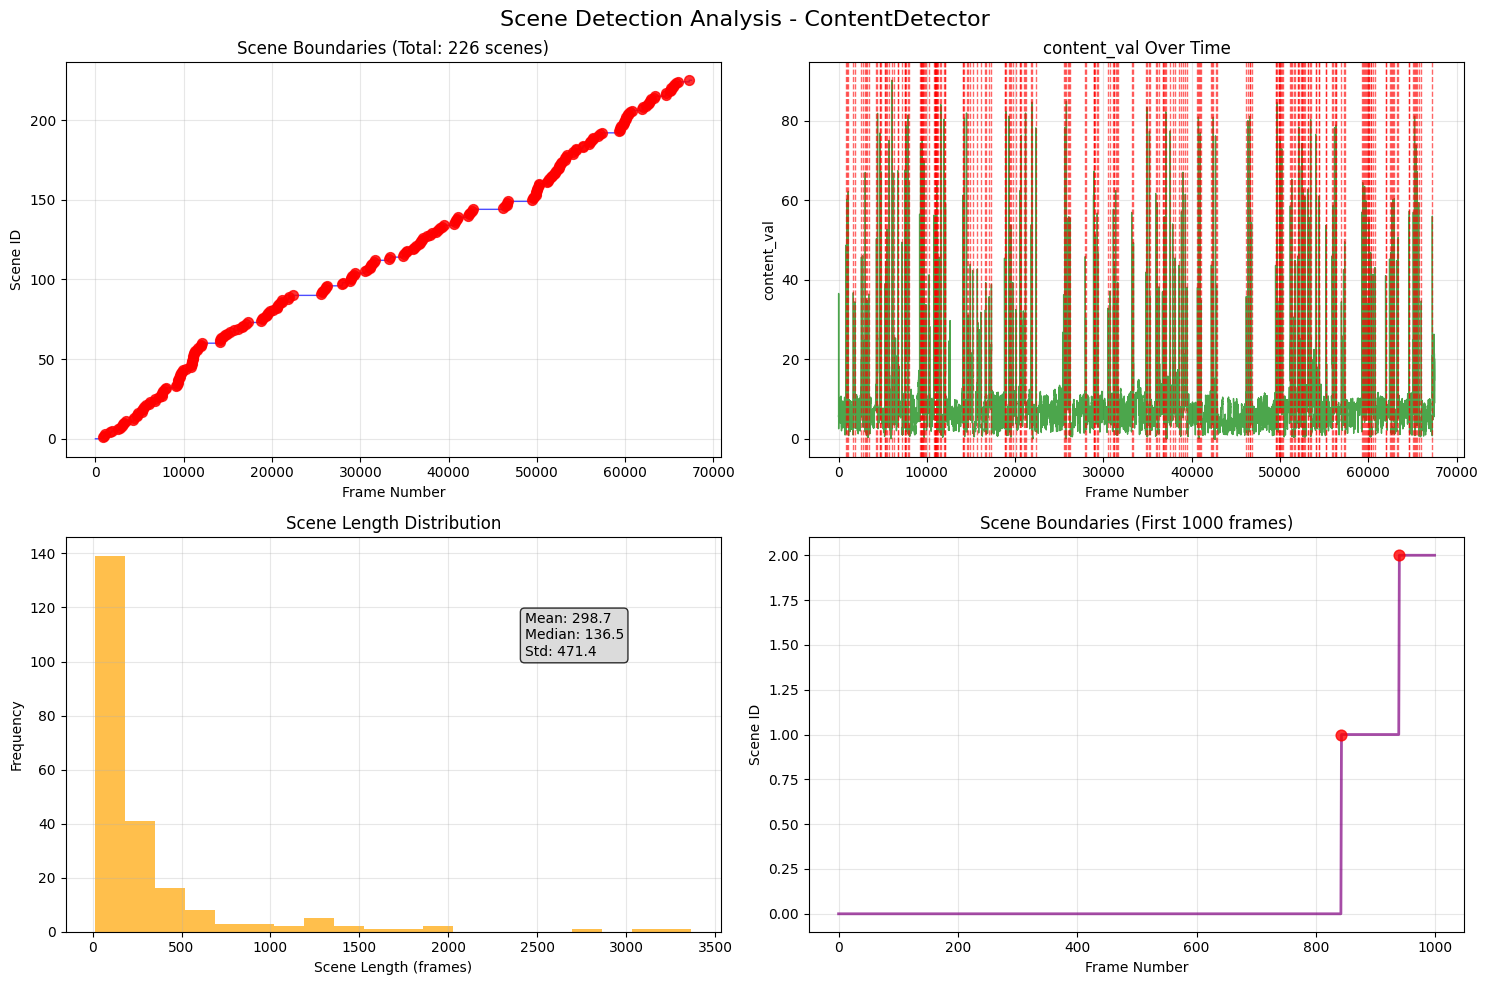


=== ContentDetector Summary ===
Total scenes detected: 226
Total frames: 67500
Average scene length: 298.67 frames
Shortest scene: 16 frames
Longest scene: 3367 frames
Scene length std dev: 471.43 frames


In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scenedetect import detect, ContentDetector, split_video_ffmpeg, SceneManager, AdaptiveDetector, ThresholdDetector, HashDetector, HistogramDetector, StatsManager, save_images, open_video
video_path = '/Users/spectatr/Downloads/soccernet_data/england_epl/2014-2015/2015-02-21 - 18-00 Chelsea 1 - 1 Burnley/2_720p.mkv'
values = {"frame_change_vals": [], "scene_id": None, "stats": None}
def scene_change(VIDEO_PATH, detector = ContentDetector(threshold=30)): #AdaptiveDetector(), ThresholdDetector(), HashDetector()
    video = open_video(VIDEO_PATH) 
    scene_id_array = np.full(video.duration.get_frames(), 0, dtype=int) # Initialise all frame to scene 0   
    stats_manager = StatsManager()
    scene_manager = SceneManager(stats_manager=stats_manager)
    scene_manager.add_detector(detector) 
    def scene_callback(frame_im, frame_num):
        values["frame_change_vals"].append(frame_num)
        # print(f"Scene cut detected at frame {frame_num}")
    scene_manager.detect_scenes(video=video,duration=video.duration, callback=scene_callback) #show_progress=True
    scene_list = scene_manager.get_scene_list()
    for i, (start_time, end_time) in enumerate(scene_list):
        start_frame = int(start_time.get_frames())
        end_frame = int(end_time.get_frames())
        scene_id_array[start_frame: end_frame] = i
    values.update({"scene_id": scene_id_array}) #updateing scene_id
    try:
        values["stats"] = stats_manager._frame_metrics # Stores all the metrics in dictionary format along with frame_number
    except Exception as e:
        print("Stats doesn't exist")
    print(f"Lenght of scene list is {len(scene_list)}")
    
    DEBUG = True
    if DEBUG==True:
        scene_manager.stats_manager.save_to_csv(csv_file=f'{detector}_cscv_stats.csv') # To save csv and find out optimal threshold by visualisations
        visualiser_scene_detect(values, detector)
        # save_images(scene_list, open_video(video_path), image_name_template='$VIDEO_NAME-Scene-$SCENE_NUMBER-$IMAGE_NUMBER', output_dir='./save_images') # Error with this: image_extension='.jpg'
scene_change(video_path)


Testing: ContentDetector_30
Length of scene list: 211


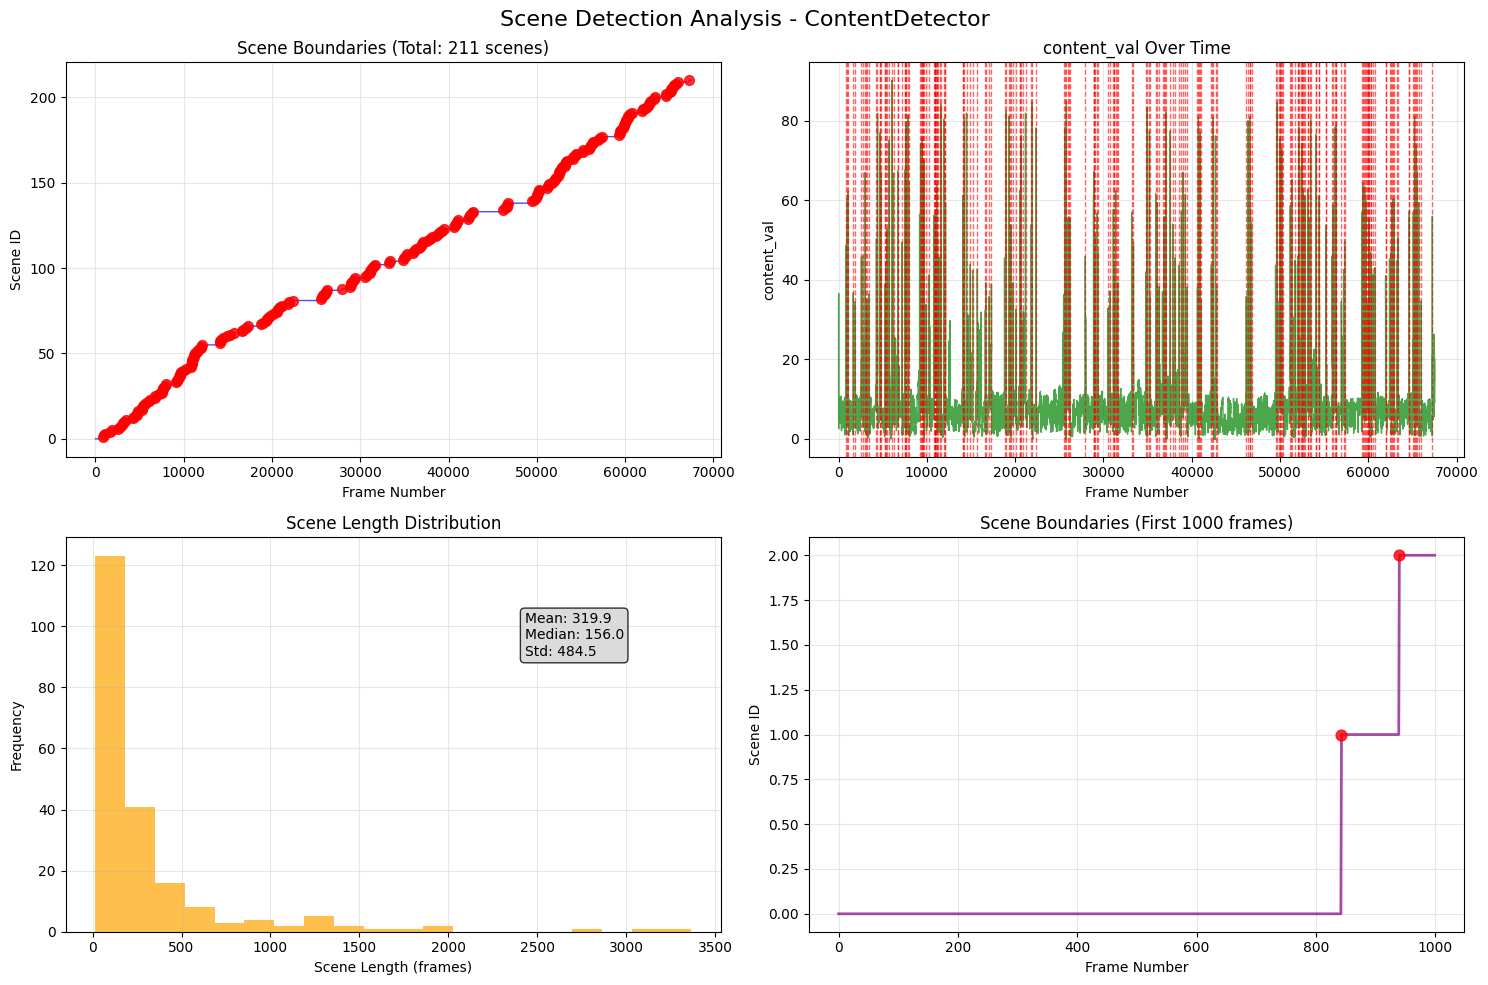


=== ContentDetector Summary ===
Total scenes detected: 211
Total frames: 67500
Average scene length: 319.91 frames
Shortest scene: 16 frames
Longest scene: 3367 frames
Scene length std dev: 484.53 frames

Testing: ContentDetector_40
Length of scene list: 188


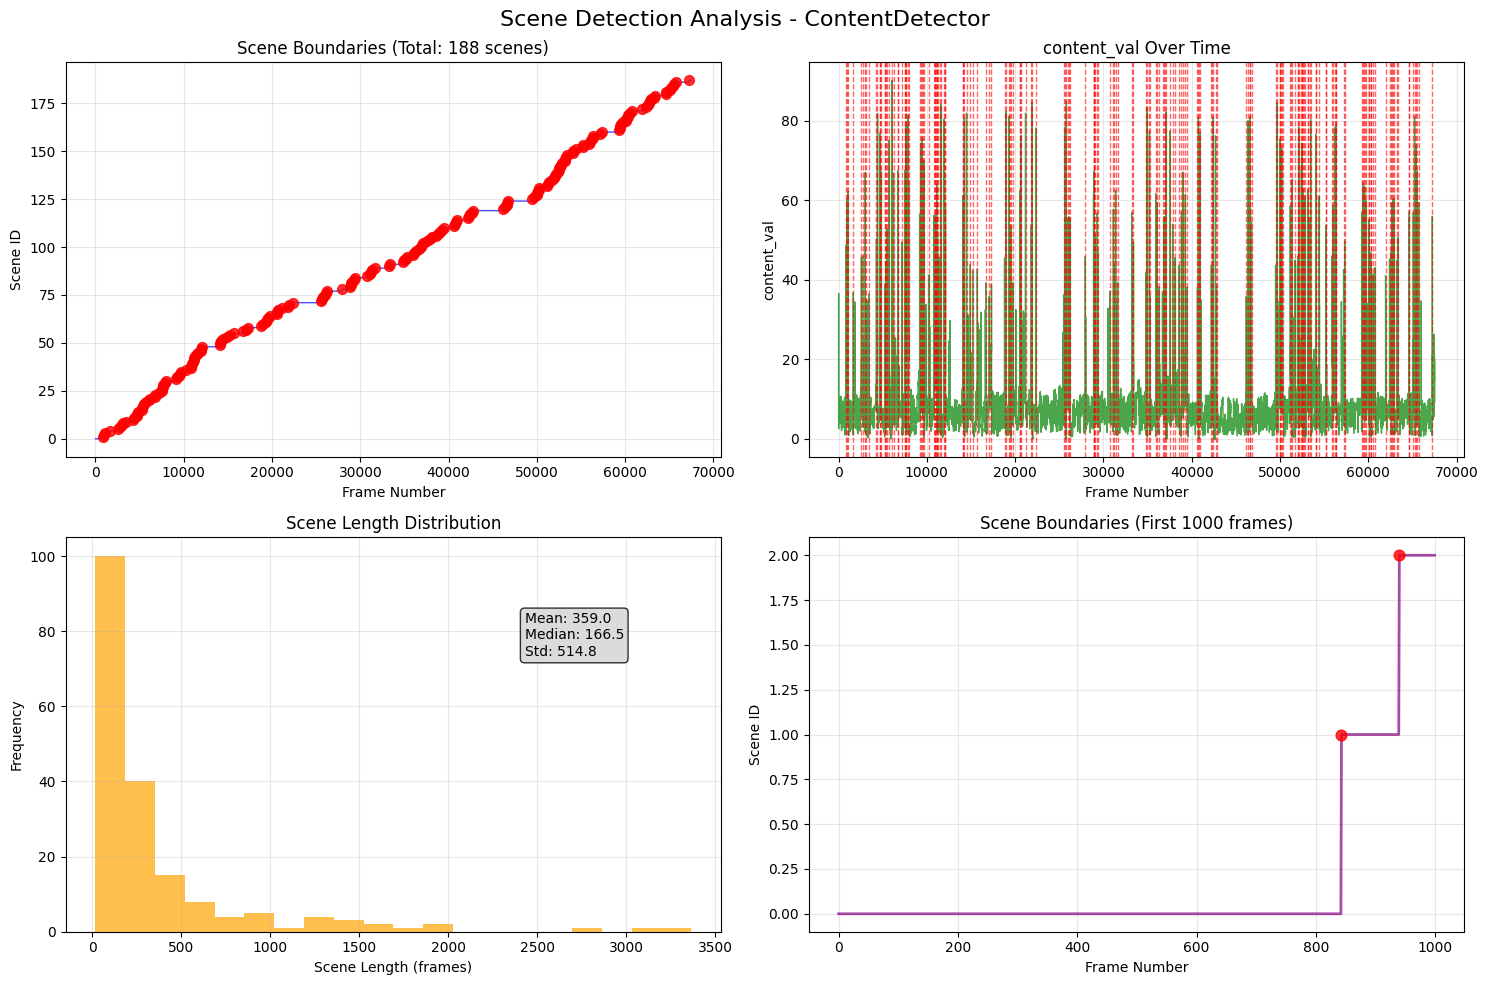


=== ContentDetector Summary ===
Total scenes detected: 188
Total frames: 67500
Average scene length: 359.04 frames
Shortest scene: 18 frames
Longest scene: 3367 frames
Scene length std dev: 514.77 frames

Testing: AdaptiveDetector_2.0
Length of scene list: 204


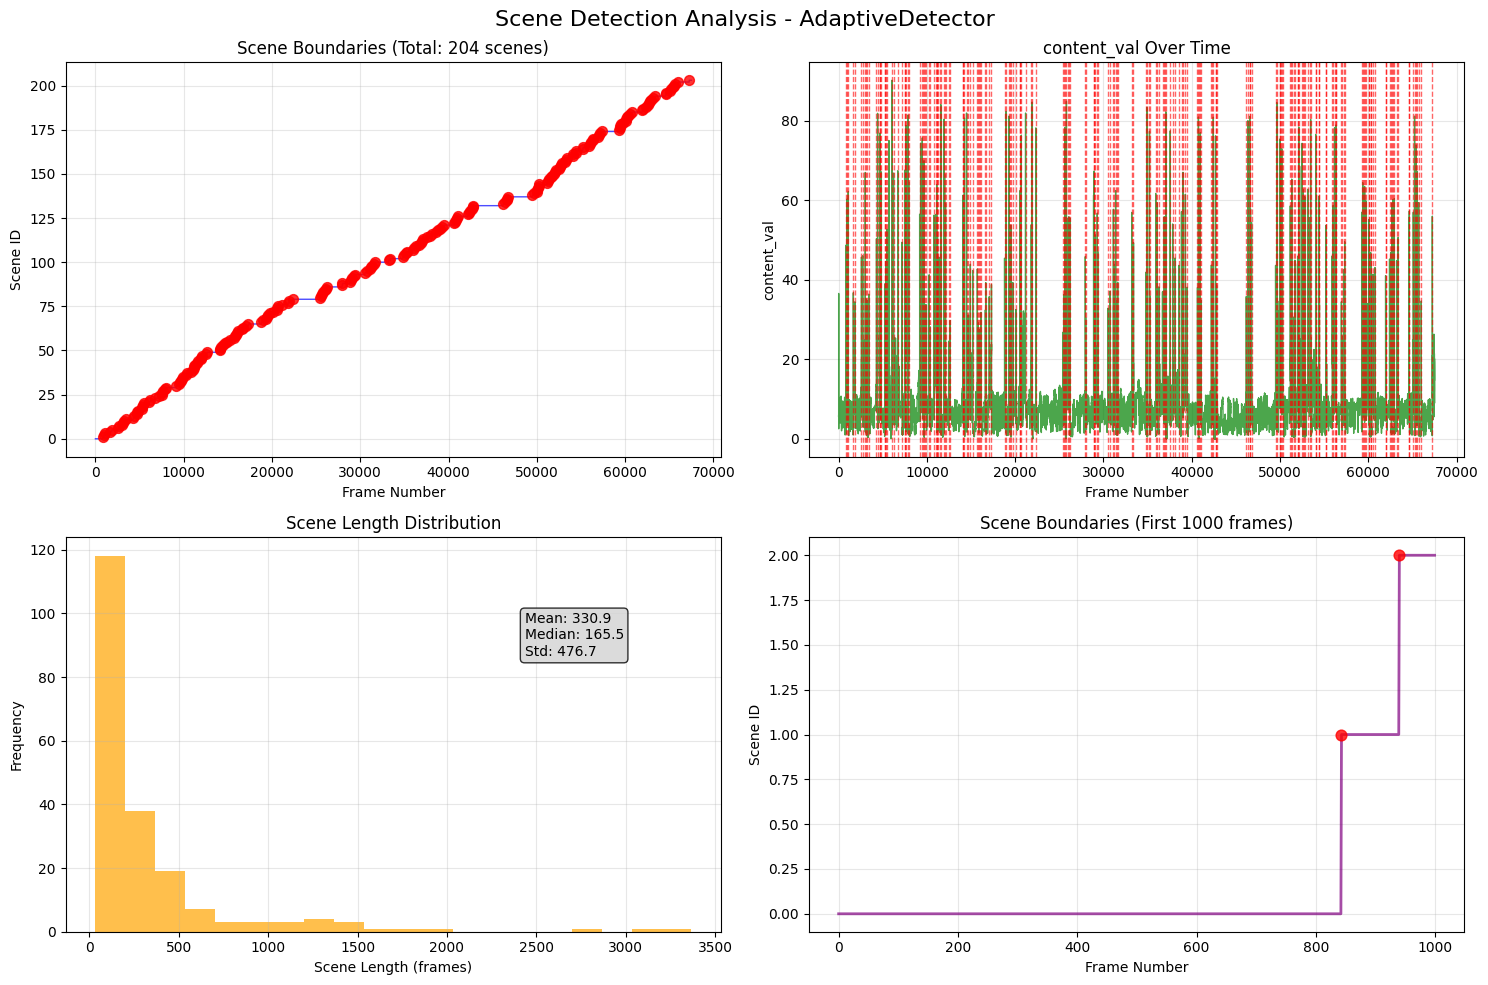


=== AdaptiveDetector Summary ===
Total scenes detected: 204
Total frames: 67500
Average scene length: 330.88 frames
Shortest scene: 34 frames
Longest scene: 3367 frames
Scene length std dev: 476.69 frames

Testing: AdaptiveDetector_3.0
Length of scene list: 185


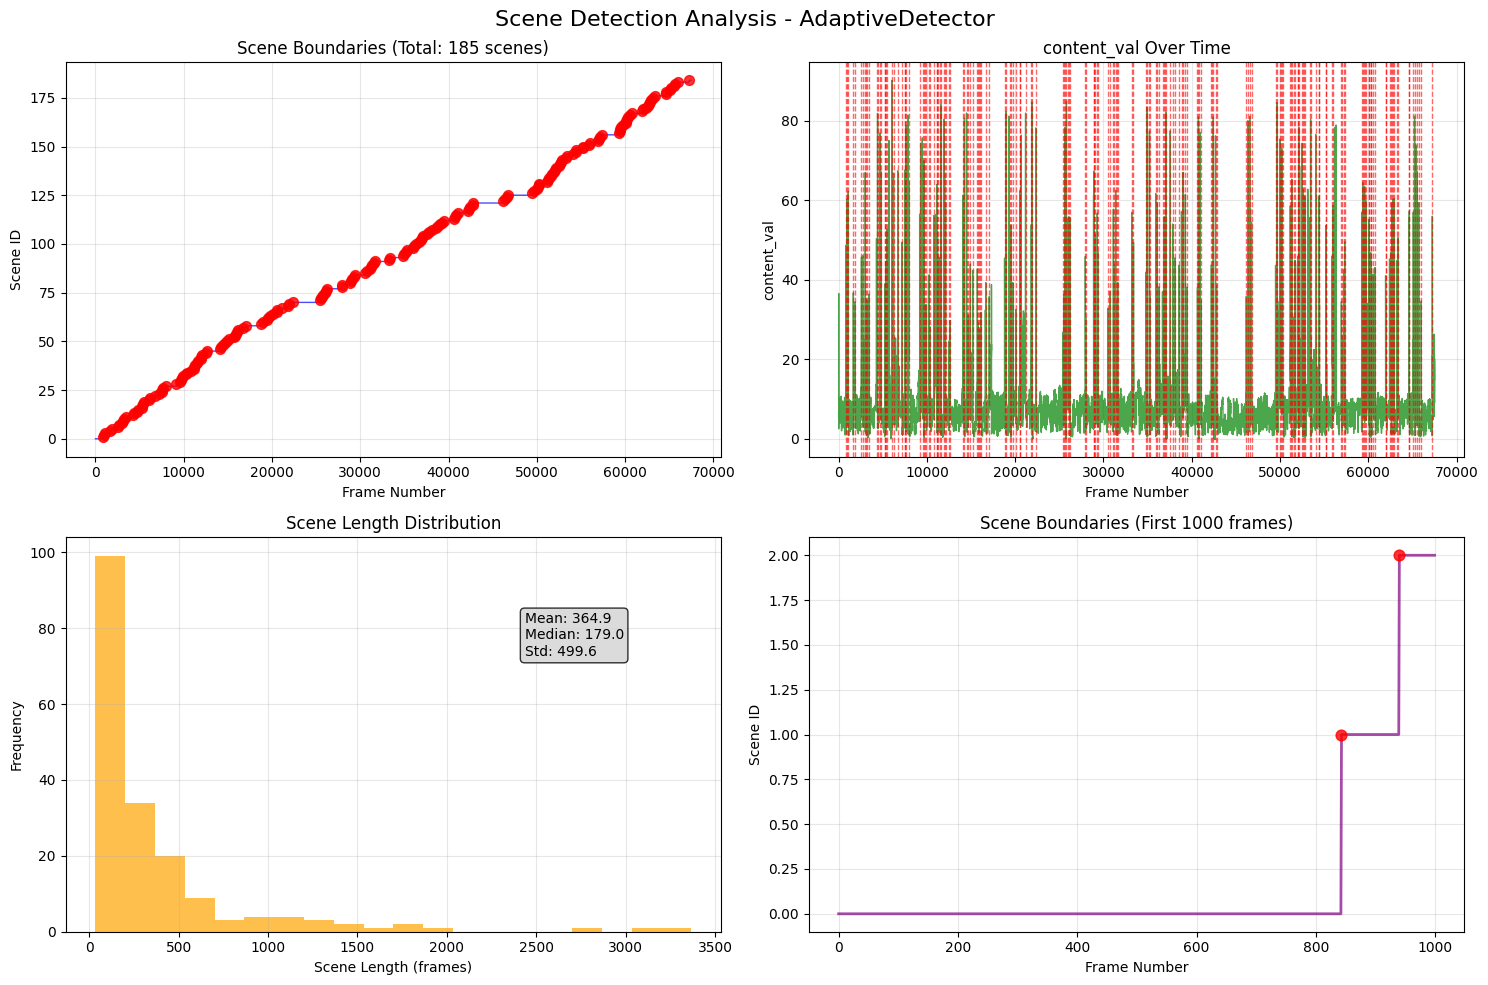


=== AdaptiveDetector Summary ===
Total scenes detected: 185
Total frames: 67500
Average scene length: 364.86 frames
Shortest scene: 35 frames
Longest scene: 3367 frames
Scene length std dev: 499.58 frames

Testing: HashDetector_0.3
Length of scene list: 191


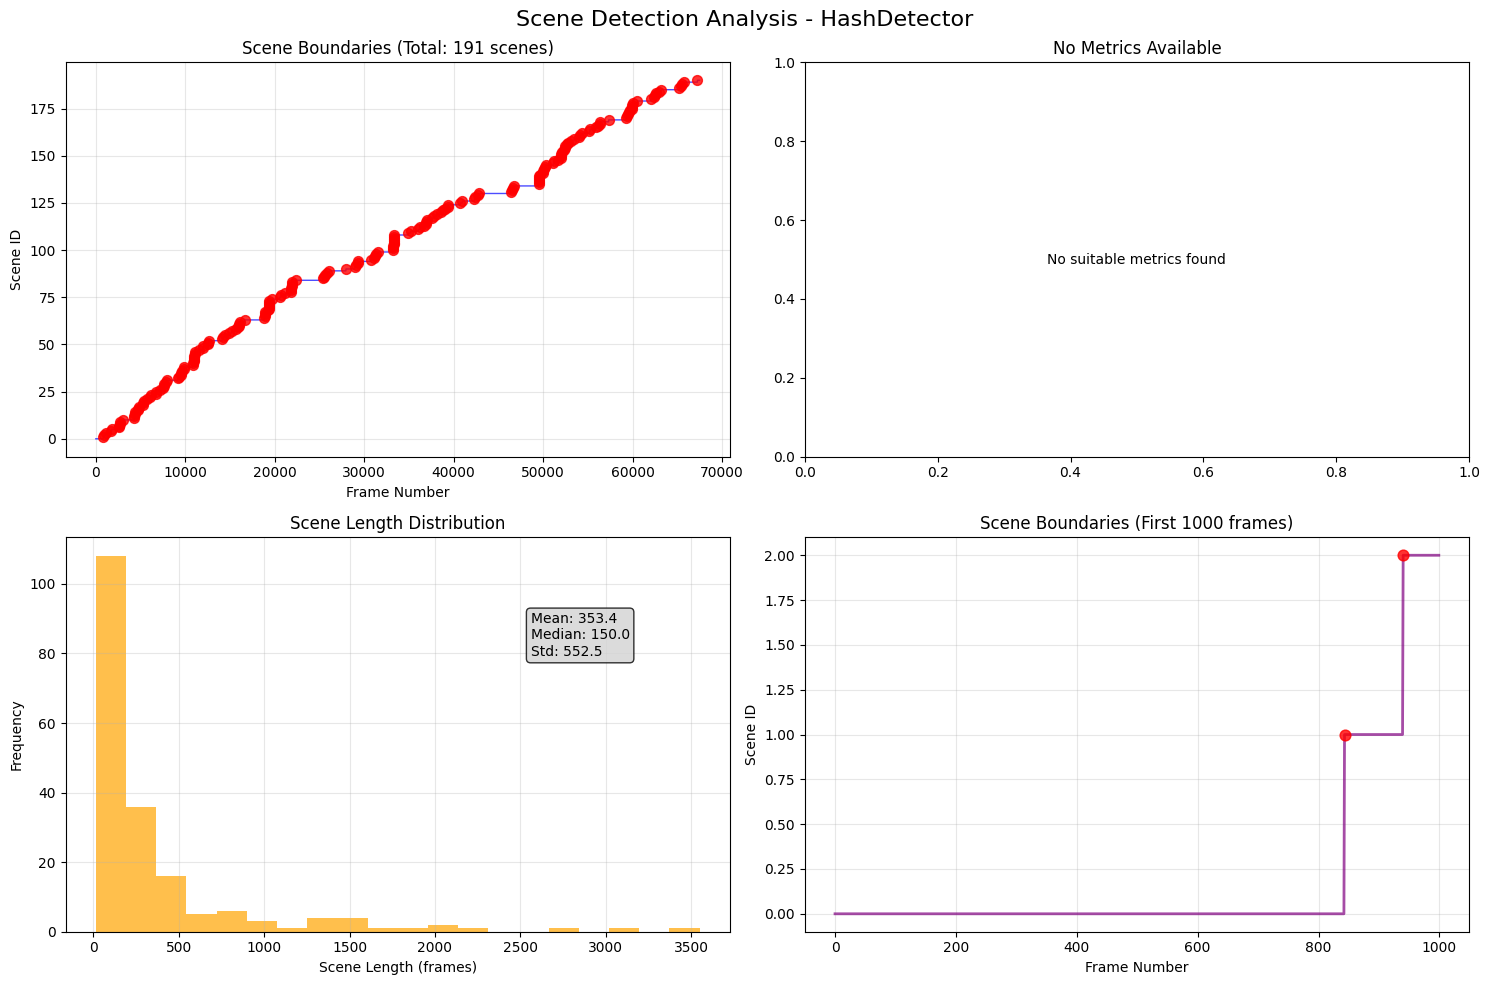


=== HashDetector Summary ===
Total scenes detected: 191
Total frames: 67500
Average scene length: 353.40 frames
Shortest scene: 15 frames
Longest scene: 3549 frames
Scene length std dev: 552.52 frames

Testing: HashDetector_0.4
Length of scene list: 83


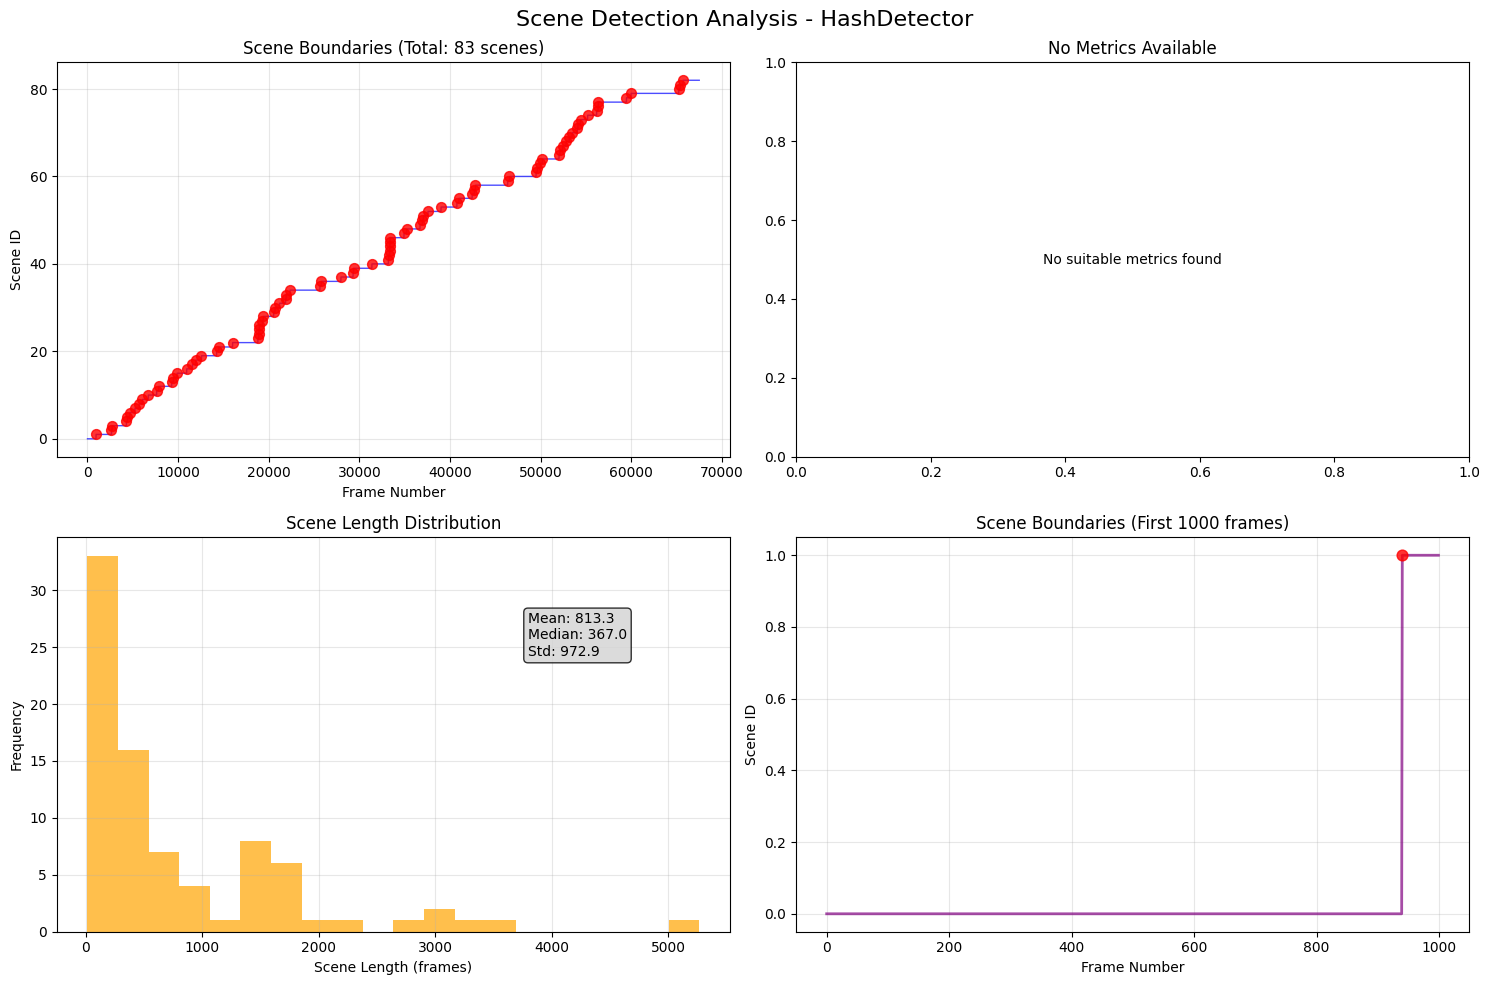


=== HashDetector Summary ===
Total scenes detected: 83
Total frames: 67500
Average scene length: 813.25 frames
Shortest scene: 15 frames
Longest scene: 5266 frames
Scene length std dev: 972.86 frames

DETECTOR COMPARISON SUMMARY
Detector                  Scenes   Avg Length   Std Length   Min      Max     
--------------------------------------------------------------------------------
ContentDetector_30        211      319.9        484.5        16       3367    
ContentDetector_40        188      359.0        514.8        18       3367    
AdaptiveDetector_2.0      204      330.9        476.7        34       3367    
AdaptiveDetector_3.0      185      364.9        499.6        35       3367    
HashDetector_0.3          191      353.4        552.5        15       3549    
HashDetector_0.4          83       813.3        972.9        15       5266    


In [ ]:
def visualiser_scene_detect(values, detector):
    """Enhanced visualization function for scene detection analysis"""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Scene Detection Analysis - {type(detector).__name__}', fontsize=16)
    
    scene_ids = values["scene_id"]
    stats = values["stats"]
    
    # Plot 1: Scene boundaries over time
    ax1 = axes[0, 0]
    scene_changes = np.where(np.diff(scene_ids) != 0)[0] + 1
    
    ax1.plot(range(len(scene_ids)), scene_ids, alpha=0.7, linewidth=1, color='blue')
    ax1.scatter(scene_changes, scene_ids[scene_changes], color='red', s=50, alpha=0.8, zorder=5)
    ax1.set_title(f'Scene Boundaries (Total: {max(scene_ids)+1 if len(scene_ids) > 0 else 0} scenes)')
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Scene ID')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Frame metrics over time
    ax2 = axes[0, 1]
    if stats:
        # Determine primary metric based on detector type
        primary_metric = None
        if isinstance(detector, ContentDetector):
            primary_metric = 'content_val'
        elif hasattr(detector, '__class__') and 'Adaptive' in detector.__class__.__name__:
            primary_metric = 'adaptive_ratio'
        elif hasattr(detector, '__class__') and 'Threshold' in detector.__class__.__name__:
            primary_metric = 'average_rgb'
        elif hasattr(detector, '__class__') and 'Hash' in detector.__class__.__name__:
            primary_metric = 'hash_diff'
        elif hasattr(detector, '__class__') and 'Histogram' in detector.__class__.__name__:
            primary_metric = 'histogram_diff'
        
        # If primary metric not found, use first available
        if not primary_metric:
            sample_frame = next(iter(stats.values()))
            primary_metric = next(iter(sample_frame.keys()), None)
        
        if primary_metric and primary_metric in next(iter(stats.values()), {}):
            frames = list(stats.keys())
            values_metric = [stats[f].get(primary_metric, 0) for f in frames]
            
            ax2.plot(frames, values_metric, alpha=0.7, linewidth=1, color='green')
            
            # Mark scene cuts
            for scene_cut in scene_changes:
                if scene_cut in frames:
                    ax2.axvline(x=scene_cut, color='red', alpha=0.6, linestyle='--', linewidth=1)
            
            ax2.set_title(f'{primary_metric} Over Time')
            ax2.set_xlabel('Frame Number')
            ax2.set_ylabel(primary_metric)
            ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, 'No suitable metrics found', 
                    ha='center', va='center', transform=ax2.transAxes)
            ax2.set_title('No Metrics Available')
    else:
        ax2.text(0.5, 0.5, 'No statistics available', 
                ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('No Statistics')
    
    # Plot 3: Scene length distribution
    ax3 = axes[1, 0]
    scene_lengths = []
    current_scene = 0
    scene_start = 0
    
    for i, scene_id in enumerate(scene_ids):
        if scene_id != current_scene:
            if i > 0:  # Don't count the first transition
                scene_lengths.append(i - scene_start)
            scene_start = i
            current_scene = scene_id
    
    # Add the last scene
    if len(scene_ids) > 0:
        scene_lengths.append(len(scene_ids) - scene_start)
    
    if scene_lengths:
        ax3.hist(scene_lengths, bins=min(20, len(set(scene_lengths))), alpha=0.7, color='orange')
        ax3.set_title('Scene Length Distribution')
        ax3.set_xlabel('Scene Length (frames)')
        ax3.set_ylabel('Frequency')
        ax3.grid(True, alpha=0.3)
        
        # Add statistics text
        stats_text = f'Mean: {np.mean(scene_lengths):.1f}\n'
        stats_text += f'Median: {np.median(scene_lengths):.1f}\n'
        stats_text += f'Std: {np.std(scene_lengths):.1f}'
        ax3.text(0.7, 0.7, stats_text, transform=ax3.transAxes, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))
    else:
        ax3.text(0.5, 0.5, 'No scenes detected', 
                ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Scene Length Distribution')
    
    # Plot 4: Scene cuts timeline (zoomed view of first 1000 frames)
    ax4 = axes[1, 1]
    zoom_frames = min(1000, len(scene_ids))
    
    if zoom_frames > 0:
        ax4.plot(range(zoom_frames), scene_ids[:zoom_frames], alpha=0.7, linewidth=2, color='purple')
        
        # Mark scene cuts in zoomed view
        zoom_cuts = [cut for cut in scene_changes if cut < zoom_frames]
        if zoom_cuts:
            ax4.scatter(zoom_cuts, scene_ids[zoom_cuts], color='red', s=60, alpha=0.8, zorder=5)
        
        ax4.set_title(f'Scene Boundaries (First {zoom_frames} frames)')
        ax4.set_xlabel('Frame Number')
        ax4.set_ylabel('Scene ID')
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'No data to display', 
                ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Zoomed View')
    
    plt.tight_layout()
    plt.savefig(f'{type(detector).__name__}_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print(f"\n=== {type(detector).__name__} Summary ===")
    print(f"Total scenes detected: {max(scene_ids)+1 if len(scene_ids) > 0 else 0}")
    print(f"Total frames: {len(scene_ids)}")
    if scene_lengths:
        print(f"Average scene length: {np.mean(scene_lengths):.2f} frames")
        print(f"Shortest scene: {min(scene_lengths)} frames")
        print(f"Longest scene: {max(scene_lengths)} frames")
        print(f"Scene length std dev: {np.std(scene_lengths):.2f} frames")


# Enhanced scene_change function with multiple detector testing
def scene_change_enhanced(video_path, detectors_list=None):
    """
    Enhanced version that tests multiple detectors and their hyperparameters
    """
    if detectors_list is None:
        # Default set of detectors to test
        detectors_list = [
            (ContentDetector(threshold=32), "ContentDetector_30"),
            # (ContentDetector(threshold=35), "ContentDetector_40"),
            # (AdaptiveDetector(adaptive_threshold=2.0), "AdaptiveDetector_2.0"), #204
            # (AdaptiveDetector(adaptive_threshold=2.5), "AdaptiveDetector_3.0"), # 185
            # (HashDetector(threshold=0.45), "HashDetector_0.3"), #0.395 # 191
            # (HashDetector(threshold=0.5), "HashDetector_0.4"), #83
        ]
    
    results_summary = []
    
    for detector, name in detectors_list:
        print(f"\n{'='*50}")
        print(f"Testing: {name}")
        print(f"{'='*50}")
        
        # Reset values for each detector
        values = {"frame_change_vals": [], "scene_id": None, "stats": None}
        
        video = open_video(video_path)
        scene_id_array = np.full(video.duration.get_frames(), 0, dtype=int)
        stats_manager = StatsManager()
        scene_manager = SceneManager(stats_manager=stats_manager)
        scene_manager.add_detector(detector)
        
        def scene_callback(frame_im, frame_num):
            values["frame_change_vals"].append(frame_num)
        
        scene_manager.detect_scenes(video=video, duration=video.duration, callback=scene_callback)
        scene_list = scene_manager.get_scene_list()
        
        for i, (start_time, end_time) in enumerate(scene_list):
            start_frame = int(start_time.get_frames())
            end_frame = int(end_time.get_frames())
            scene_id_array[start_frame: end_frame] = i
        
        values.update({"scene_id": scene_id_array})
        
        try:
            values["stats"] = stats_manager._frame_metrics
        except Exception as e:
            print("Stats doesn't exist")
        
        print(f"Length of scene list: {len(scene_list)}")
        
        # Save stats and visualize
        try:
            scene_manager.stats_manager.save_to_csv(csv_file=f'{name}_stats.csv')
        except:
            print("Could not save CSV stats")
        
        visualiser_scene_detect(values, detector)
        
        # Store summary for comparison
        scene_lengths = [(end_time - start_time).get_frames() for start_time, end_time in scene_list]
        results_summary.append({
            'detector_name': name,
            'num_scenes': len(scene_list),
            'avg_scene_length': np.mean(scene_lengths) if scene_lengths else 0,
            'std_scene_length': np.std(scene_lengths) if scene_lengths else 0,
            'min_scene_length': min(scene_lengths) if scene_lengths else 0,
            'max_scene_length': max(scene_lengths) if scene_lengths else 0
        })
    
    # Print comparison summary
    print(f"\n{'='*80}")
    print("DETECTOR COMPARISON SUMMARY")
    print(f"{'='*80}")
    print(f"{'Detector':<25} {'Scenes':<8} {'Avg Length':<12} {'Std Length':<12} {'Min':<8} {'Max':<8}")
    print(f"{'-'*80}")
    
    for result in results_summary:
        print(f"{result['detector_name']:<25} {result['num_scenes']:<8} "
              f"{result['avg_scene_length']:<12.1f} {result['std_scene_length']:<12.1f} "
              f"{result['min_scene_length']:<8} {result['max_scene_length']:<8}")
    
    return results_summary

# Example usage:
results = scene_change_enhanced(video_path)

In [68]:
StatsManager().metric_keys

set()

content_val
delta_hue
delta_sat
delta_lum
delta_edges


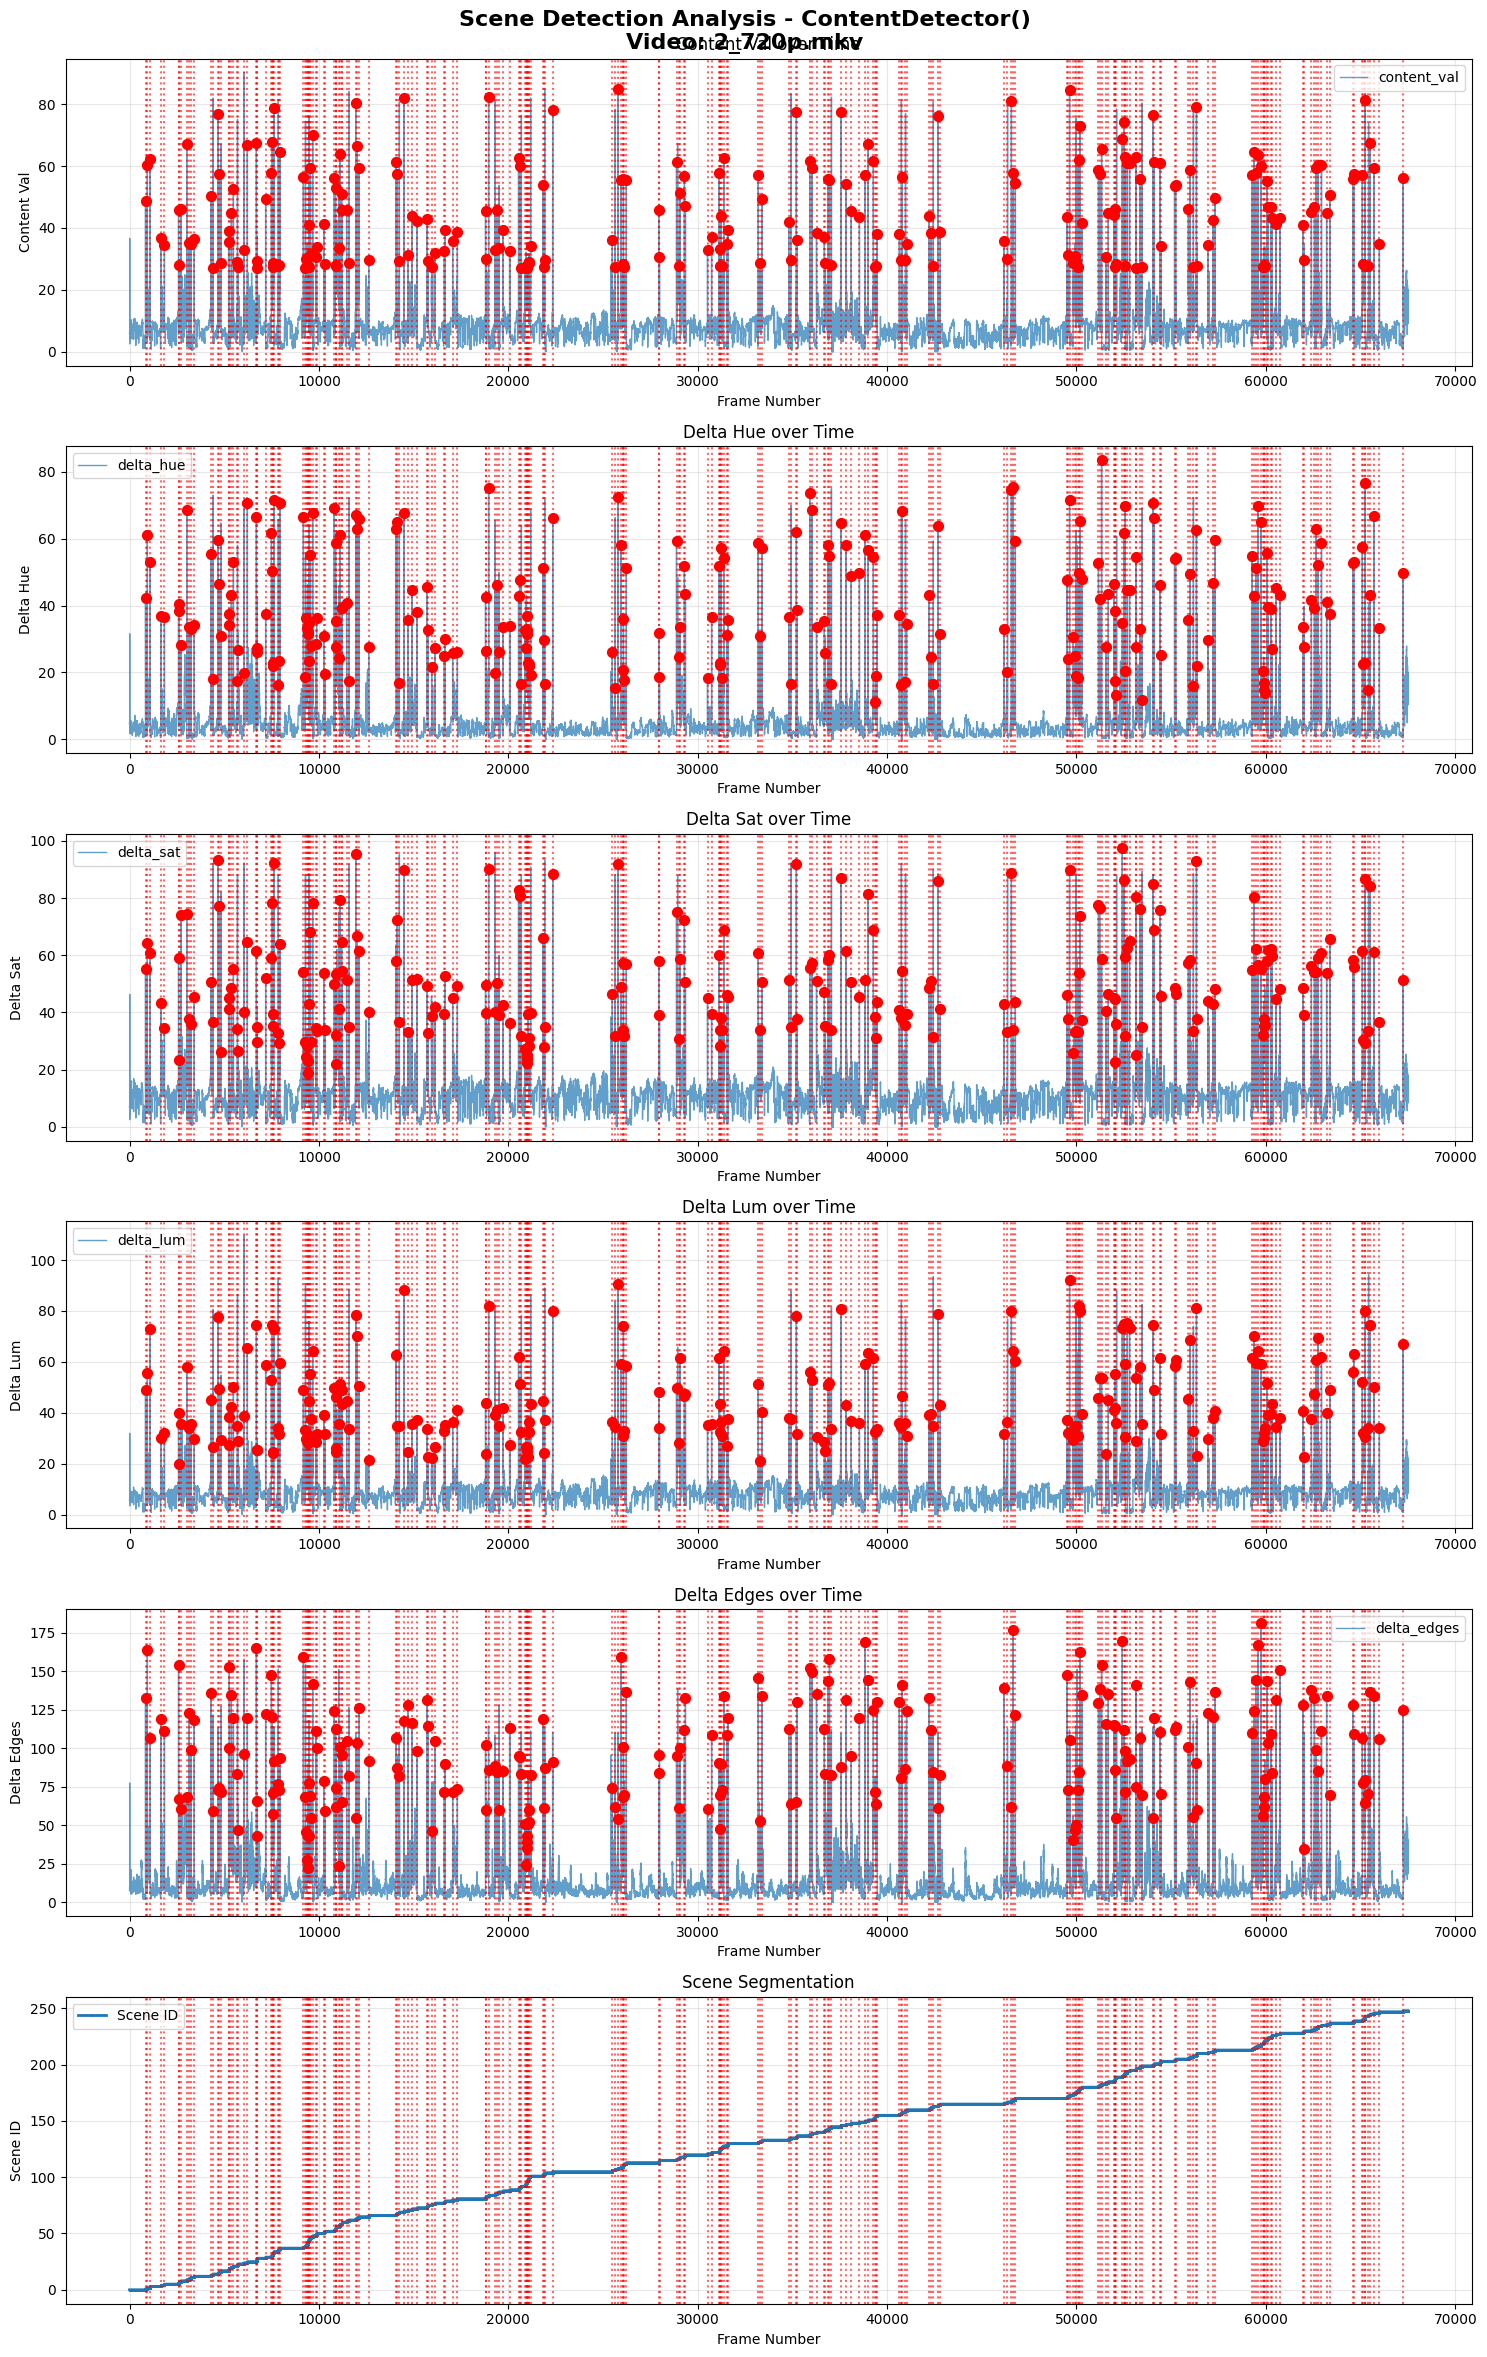

In [ ]:
# values["stats"]
# import pandas as pd
# flattened_data = []
# for frame_num, metrics in values["stats"].items():
#     row = {'frame_number': frame_num}
#     for metric_name, value in metrics.items():
#         # Convert numpy types to regular Python types
#         if hasattr(value, 'item'):
#             row[metric_name] = value.item()
#         else:
#             row[metric_name] = value
#     flattened_data.append(row)

# df = pd.DataFrame(flattened_data)
# df = df.sort_values('frame_number').reset_index(drop=True)

import matplotlib.pyplot as plt
import numpy as np


# Extract data from dictionary format
stats_dict = values["stats"]
scene_cuts = values["frame_change_vals"]
detector_name = "ContentDetector()"


In [33]:
# Simple threshold analyzer that works with your existing code
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def analyze_existing_stats(csv_path, target_scenes=200, detector_type='adaptive'):
    """
    Simple function to analyze your existing stats CSV and find optimal threshold
    """
    
    # Load your existing stats
    df = pd.read_csv(csv_path)
    print(f"Loaded stats with {len(df)} frames")
    print(f"Available columns: {list(df.columns)}")
    
    # Determine metric column based on detector type
    metric_mapping = {
        'adaptive': ['adaptive_ratio', 'content_val'],  # Adaptive uses both
        'content': ['content_val'],
        'threshold': ['delta_rgb'],
        'hash': ['hash_dist'],
        'histogram': ['hist_diff']
    }
    
    # Find the right metric column
    possible_metrics = metric_mapping.get(detector_type, ['content_val'])
    metric_column = None
    
    for metric in possible_metrics:
        if metric in df.columns:
            metric_column = metric
            break
    
    if metric_column is None:
        print(f"Could not find appropriate metric column for {detector_type} detector")
        print(f"Available columns: {list(df.columns)}")
        return None
    
    print(f"Using metric column: {metric_column}")
    
    # Analyze different threshold values
    if detector_type == 'adaptive':
        # For adaptive detector, test adaptive_threshold values
        thresholds = np.arange(1.0, 5.0, 0.1)
        
        # Simulate adaptive detection (simplified)
        results = []
        for threshold in thresholds:
            # Count frames where adaptive_ratio > threshold
            if 'adaptive_ratio' in df.columns:
                scene_cuts = len(df[df['adaptive_ratio'] > threshold])
            else:
                # Fallback to content_val if adaptive_ratio not available
                scene_cuts = len(df[df[metric_column] > threshold * 10])  # Rough conversion
            
            results.append({
                'threshold': threshold,
                'scene_count': scene_cuts,
                'distance_from_target': abs(scene_cuts - target_scenes)
            })
    
    elif detector_type == 'content':
        # For content detector, test threshold values
        thresholds = np.arange(15, 50, 0.5)
        results = []
        for threshold in thresholds:
            scene_cuts = len(df[df[metric_column] > threshold])
            results.append({
                'threshold': threshold,
                'scene_count': scene_cuts,
                'distance_from_target': abs(scene_cuts - target_scenes)
            })
    
    else:
        print(f"Detector type {detector_type} not fully implemented in simple version")
        return None
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Find optimal threshold
    best_idx = results_df['distance_from_target'].idxmin()
    optimal_threshold = results_df.loc[best_idx, 'threshold']
    optimal_scenes = results_df.loc[best_idx, 'scene_count']
    
    # Create visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Metric values over time
    ax1.plot(df['Frame Number'], df[metric_column], linewidth=0.8, alpha=0.7)
    ax1.axhline(y=optimal_threshold, color='red', linestyle='--', 
                label=f'Optimal Threshold: {optimal_threshold:.2f}')
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel(metric_column)
    ax1.set_title(f'{detector_type.capitalize()} Detector: {metric_column} Over Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Threshold vs Scene Count
    ax2.plot(results_df['threshold'], results_df['scene_count'], 'b-', linewidth=2)
    ax2.axhline(y=target_scenes, color='green', linestyle='--', 
                label=f'Target: {target_scenes} scenes')
    ax2.axvline(x=optimal_threshold, color='red', linestyle='--', 
                label=f'Optimal: {optimal_threshold:.2f}')
    ax2.scatter([optimal_threshold], [optimal_scenes], color='red', s=100, zorder=5)
    ax2.set_xlabel('Threshold Value')
    ax2.set_ylabel('Number of Detected Scenes')
    ax2.set_title('Threshold Sensitivity Analysis')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Histogram of metric values
    ax3.hist(df[metric_column], bins=50, alpha=0.7, edgecolor='black')
    ax3.axvline(x=optimal_threshold, color='red', linestyle='--', 
                label=f'Optimal: {optimal_threshold:.2f}')
    ax3.set_xlabel(metric_column)
    ax3.set_ylabel('Frequency')
    ax3.set_title(f'Distribution of {metric_column} Values')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Distance from target
    ax4.plot(results_df['threshold'], results_df['distance_from_target'], 'g-', linewidth=2)
    ax4.axvline(x=optimal_threshold, color='red', linestyle='--', 
                label=f'Optimal: {optimal_threshold:.2f}')
    ax4.set_xlabel('Threshold Value')
    ax4.set_ylabel('Distance from Target Scene Count')
    ax4.set_title('Threshold Optimization')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{detector_type}_threshold_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print recommendations
    print("\n" + "="*60)
    print(f"THRESHOLD ANALYSIS RESULTS FOR {detector_type.upper()} DETECTOR")
    print("="*60)
    print(f"Target Scenes: {target_scenes}")
    print(f"Optimal Threshold: {optimal_threshold:.3f}")
    print(f"Resulting Scene Count: {optimal_scenes}")
    print(f"Distance from Target: {abs(optimal_scenes - target_scenes)}")
    
    # Show top 5 alternatives
    top_alternatives = results_df.nsmallest(5, 'distance_from_target')
    print(f"\nTop 5 Threshold Options:")
    print("-" * 40)
    for _, row in top_alternatives.iterrows():
        print(f"Threshold: {row['threshold']:.3f} → {row['scene_count']} scenes (±{row['distance_from_target']:.0f})")
    
    return {
        'optimal_threshold': optimal_threshold,
        'optimal_scenes': optimal_scenes,
        'results_df': results_df,
        'metric_column': metric_column
    }

# Function to work directly with your existing code:
def quick_threshold_analysis():
    """
    Quick analysis using your existing setup
    """
    csv_path = '/Users/spectatr/Downloads/general_scripts/model_improvement_experiments/threshold_stats.csv'
    
    # Since you used AdaptiveDetector, analyze for adaptive threshold
    results = analyze_existing_stats(
        csv_path=csv_path,
        target_scenes=200,
        detector_type='adaptive'
    )
    
    if results:
        optimal_threshold = results['optimal_threshold']
        
        print(f"\n🎯 RECOMMENDATION:")
        print(f"Use AdaptiveDetector(adaptive_threshold={optimal_threshold:.2f}) for ~200 scenes")
        
        # Generate the code snippet
        print(f"\n📝 CODE TO USE:")
        print(f"scene_manager.add_detector(AdaptiveDetector(adaptive_threshold={optimal_threshold:.2f}))")
    
    return results

# Run the analysis
if __name__ == "__main__":
    results = quick_threshold_analysis()

Loaded stats with 67499 frames
Available columns: ['Frame Number', 'Timecode', 'adaptive_ratio (w=2)', 'content_val', 'delta_edges', 'delta_hue', 'delta_lum', 'delta_sat']
Using metric column: content_val

THRESHOLD ANALYSIS RESULTS FOR ADAPTIVE DETECTOR
Target Scenes: 200
Optimal Threshold: 4.900
Resulting Scene Count: 218
Distance from Target: 18

Top 5 Threshold Options:
----------------------------------------
Threshold: 4.900 → 218.0 scenes (±18)
Threshold: 4.800 → 232.0 scenes (±32)
Threshold: 4.700 → 244.0 scenes (±44)
Threshold: 4.600 → 258.0 scenes (±58)
Threshold: 4.500 → 277.0 scenes (±77)

🎯 RECOMMENDATION:
Use AdaptiveDetector(adaptive_threshold=4.90) for ~200 scenes

📝 CODE TO USE:
scene_manager.add_detector(AdaptiveDetector(adaptive_threshold=4.90))


In [ ]:
split_video_ffmpeg(video_path, scene_list, output_file_template='$VIDEO_NAME-Scene-$SCENE_NUMBER.mp4')

- Manually done- number of frame counts: **210**
- custom our algorithm took 20 minutes to extract framechange with **209** frames
- Lenght is 307 for HashDetector took 2minutes.
- Scene Detector is 153 frames in 30 seconds
- content dectector took 2 minutes for 270 frames
- Adaptive only created 152 = wrong
- Histogram detector took = 2 minuste with 318
After gettting hyperparameters run old code and this code and check the difference.

In [ ]:
for i, scene in enumerate(scene_list):
    print('    Scene %2d: Start %s / Frame %d, End %s / Frame %d' % (
        i+1,
        scene[0].get_timecode(), scene[0].get_frames(),
        scene[1].get_timecode(), scene[1].get_frames(),))
# Scene  1: Start 00:00:00.000 / Frame 0, End 00:00:33.720 / Frame 843
# Scene  2: Start 00:00:33.720 / Frame 843, End 00:00:37.600 / Frame 940

In [24]:
from scenedetect import detect, ContentDetector, split_video_ffmpeg, SceneManager, AdaptiveDetector, ThresholdDetector, HashDetector, HistogramDetector, StatsManager, open_video
video_path = '/Users/spectatr/Downloads/soccernet_data/england_epl/2014-2015/2015-02-21 - 18-00 Chelsea 1 - 1 Burnley/2_720p.mkv'
video = open_video(video_path)
scene_manager = SceneManager(stats_manager=StatsManager())
# scene_manager.add_detector(ThresholdDetector()) # Can add multiple detectors. Threshold is to detect fades in/out
scene_manager.add_detector(AdaptiveDetector()) #Hash Detector
scene_manager.detect_scenes(video=video)
scene_list = scene_manager.get_scene_list()
print(scene_list)
# print_scenes(scene_list=scene_list)
scene_manager.stats_manager.save_to_csv(csv_file='/Users/spectatr/Downloads/general_scripts/model_improvement_experiments/threshold_stats.csv')

[(00:00:00.000 [frame=0, fps=25.000], 00:00:33.720 [frame=843, fps=25.000]), (00:00:33.720 [frame=843, fps=25.000], 00:00:37.600 [frame=940, fps=25.000]), (00:00:37.600 [frame=940, fps=25.000], 00:00:43.680 [frame=1092, fps=25.000]), (00:00:43.680 [frame=1092, fps=25.000], 00:01:06.720 [frame=1668, fps=25.000]), (00:01:06.720 [frame=1668, fps=25.000], 00:01:13.680 [frame=1842, fps=25.000]), (00:01:13.680 [frame=1842, fps=25.000], 00:01:43.520 [frame=2588, fps=25.000]), (00:01:43.520 [frame=2588, fps=25.000], 00:01:48.960 [frame=2724, fps=25.000]), (00:01:48.960 [frame=2724, fps=25.000], 00:02:00.840 [frame=3021, fps=25.000]), (00:02:00.840 [frame=3021, fps=25.000], 00:02:05.640 [frame=3141, fps=25.000]), (00:02:05.640 [frame=3141, fps=25.000], 00:02:10.160 [frame=3254, fps=25.000]), (00:02:10.160 [frame=3254, fps=25.000], 00:02:16.640 [frame=3416, fps=25.000]), (00:02:16.640 [frame=3416, fps=25.000], 00:02:51.600 [frame=4290, fps=25.000]), (00:02:51.600 [frame=4290, fps=25.000], 00:03:

In [32]:
# To visualise the csv saved from StatsManager
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.widgets import Slider
from scipy import signal
import warnings
import os

warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def load_and_analyze_data(csv_file_path):
    """Load CSV data and perform initial analysis"""
    # Load the data
    df = pd.read_csv(csv_file_path)
    
    # Convert timecode to seconds for easier analysis
    def timecode_to_seconds(timecode):
        parts = timecode.split(':')
        hours, minutes, seconds = float(parts[0]), float(parts[1]), float(parts[2])
        return hours * 3600 + minutes * 60 + seconds
    
    df['time_seconds'] = df['Timecode'].apply(timecode_to_seconds)
    
    return df

def create_comprehensive_plots(df):
    """Create multiple visualization plots for threshold analysis"""
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Time series plot of all metrics
    ax1 = plt.subplot(3, 2, 1)
    metrics = ['content_val', 'delta_edges', 'delta_hue', 'delta_lum', 'delta_sat']
    for metric in metrics:
        plt.plot(df['time_seconds'], df[metric], label=metric, linewidth=2, alpha=0.8)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Detection Values')
    plt.title('All Detection Metrics Over Time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2. Focus on content_val with potential thresholds
    ax2 = plt.subplot(3, 2, 2)
    plt.plot(df['time_seconds'], df['content_val'], 'b-', linewidth=2, label='content_val')
    
    # Add threshold lines
    content_mean = df['content_val'].mean()
    content_std = df['content_val'].std()
    thresholds = [
        content_mean + content_std,
        content_mean + 2*content_std,
        content_mean + 1.5*content_std
    ]
    
    colors = ['red', 'orange', 'green']
    labels = ['Mean + 1σ', 'Mean + 2σ', 'Mean + 1.5σ']
    
    for threshold, color, label in zip(thresholds, colors, labels):
        plt.axhline(y=threshold, color=color, linestyle='--', alpha=0.7, label=f'{label}: {threshold:.2f}')
    
    plt.xlabel('Time (seconds)')
    plt.ylabel('Content Value')
    plt.title('Content Value with Suggested Thresholds')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. Distribution analysis
    ax3 = plt.subplot(3, 2, 3)
    plt.hist(df['content_val'], bins=30, alpha=0.7, edgecolor='black')
    for threshold, color, label in zip(thresholds, colors, labels):
        plt.axvline(x=threshold, color=color, linestyle='--', linewidth=2, label=f'{label}: {threshold:.2f}')
    plt.xlabel('Content Value')
    plt.ylabel('Frequency')
    plt.title('Distribution of Content Values')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 4. Correlation heatmap
    ax4 = plt.subplot(3, 2, 4)
    correlation_matrix = df[metrics].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.2f', cbar_kws={"shrink": .8})
    plt.title('Correlation Between Detection Metrics')
    
    # 5. Box plot comparison
    ax5 = plt.subplot(3, 2, 5)
    df_melted = pd.melt(df, id_vars=['Frame Number'], value_vars=metrics, 
                       var_name='Metric', value_name='Value')
    sns.boxplot(data=df_melted, x='Metric', y='Value')
    plt.xticks(rotation=45)
    plt.title('Distribution Comparison of All Metrics')
    plt.tight_layout()
    
    # 6. Derivative analysis for content_val
    ax6 = plt.subplot(3, 2, 6)
    content_derivative = np.gradient(df['content_val'])
    plt.plot(df['time_seconds'], content_derivative, 'purple', linewidth=2, label='Content Value Derivative')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Mark significant changes
    significant_changes = np.abs(content_derivative) > np.std(content_derivative) * 2
    plt.scatter(df['time_seconds'][significant_changes], 
               content_derivative[significant_changes], 
               color='red', s=50, alpha=0.7, label='Significant Changes')
    
    plt.xlabel('Time (seconds)')
    plt.ylabel('Rate of Change')
    plt.title('Content Value Rate of Change (Potential Scene Cuts)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

def interactive_threshold_explorer(df):
    """Create an interactive plot to explore different threshold values"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    
    # Initial threshold
    initial_threshold = df['content_val'].mean() + df['content_val'].std()
    
    # Plot 1: Time series with threshold
    line1, = ax1.plot(df['time_seconds'], df['content_val'], 'b-', linewidth=2, label='content_val')
    threshold_line, = ax1.plot(df['time_seconds'], [initial_threshold] * len(df), 
                              'r--', linewidth=2, label=f'Threshold: {initial_threshold:.2f}')
    
    # Mark detected scenes
    scenes = df['content_val'] > initial_threshold
    scene_points = ax1.scatter(df['time_seconds'][scenes], df['content_val'][scenes], 
                              color='red', s=50, alpha=0.7, label='Detected Scenes')
    
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('Content Value')
    ax1.set_title('Interactive Threshold Explorer')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Statistics
    ax2.text(0.1, 0.8, f'Total Frames: {len(df)}', transform=ax2.transAxes, fontsize=12)
    ax2.text(0.1, 0.7, f'Detected Scenes: {np.sum(scenes)}', transform=ax2.transAxes, fontsize=12)
    ax2.text(0.1, 0.6, f'Detection Rate: {np.sum(scenes)/len(df)*100:.1f}%', transform=ax2.transAxes, fontsize=12)
    ax2.text(0.1, 0.5, f'Avg Time Between Scenes: {len(df)/np.sum(scenes)*0.04:.2f}s', 
             transform=ax2.transAxes, fontsize=12)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.axis('off')
    
    # Add slider
    ax_slider = plt.axes([0.2, 0.02, 0.6, 0.03])
    slider = Slider(ax_slider, 'Threshold', 
                   df['content_val'].min(), df['content_val'].max(), 
                   valinit=initial_threshold, valstep=0.1)
    
    def update_threshold(val):
        threshold = slider.val
        threshold_line.set_ydata([threshold] * len(df))
        
        # Update scene detection
        scenes = df['content_val'] > threshold
        scene_points.set_offsets(np.column_stack([df['time_seconds'][scenes], df['content_val'][scenes]]))
        
        # Update statistics
        ax2.clear()
        ax2.text(0.1, 0.8, f'Total Frames: {len(df)}', transform=ax2.transAxes, fontsize=12)
        ax2.text(0.1, 0.7, f'Detected Scenes: {np.sum(scenes)}', transform=ax2.transAxes, fontsize=12)
        ax2.text(0.1, 0.6, f'Detection Rate: {np.sum(scenes)/len(df)*100:.1f}%', transform=ax2.transAxes, fontsize=12)
        if np.sum(scenes) > 0:
            ax2.text(0.1, 0.5, f'Avg Time Between Scenes: {len(df)/np.sum(scenes)*0.04:.2f}s', 
                     transform=ax2.transAxes, fontsize=12)
        ax2.text(0.1, 0.4, f'Current Threshold: {threshold:.2f}', transform=ax2.transAxes, fontsize=12)
        ax2.set_xlim(0, 1)
        ax2.set_ylim(0, 1)
        ax2.axis('off')
        
        threshold_line.set_label(f'Threshold: {threshold:.2f}')
        ax1.legend()
        fig.canvas.draw()
    
    slider.on_changed(update_threshold)
    
    plt.tight_layout()
    return fig, slider

def generate_recommendations(df):
    """Generate threshold recommendations based on statistical analysis"""
    content_vals = df['content_val']
    
    # Statistical measures
    mean_val = content_vals.mean()
    std_val = content_vals.std()
    median_val = content_vals.median()
    q75 = content_vals.quantile(0.75)
    q90 = content_vals.quantile(0.90)
    q95 = content_vals.quantile(0.95)
    
    print("=== THRESHOLD RECOMMENDATIONS ===\n")
    
    print(f"Statistical Summary:")
    print(f"  Mean: {mean_val:.2f}")
    print(f"  Std Dev: {std_val:.2f}")
    print(f"  Median: {median_val:.2f}")
    print(f"  75th Percentile: {q75:.2f}")
    print(f"  90th Percentile: {q90:.2f}")
    print(f"  95th Percentile: {q95:.2f}\n")
    
    recommendations = [
        ("Conservative (fewer scenes)", q95, "Detects only the most significant changes"),
        ("Moderate", mean_val + 1.5*std_val, "Balanced approach, good starting point"),
        ("Sensitive", q75, "Detects more subtle changes"),
        ("Very Sensitive", median_val, "May catch too many minor changes")
    ]
    
    print("Recommended Thresholds:")
    for name, threshold, description in recommendations:
        scenes_detected = np.sum(content_vals > threshold)
        detection_rate = scenes_detected / len(df) * 100
        print(f"  {name}: {threshold:.2f}")
        print(f"    - {description}")
        print(f"    - Would detect {scenes_detected} scenes ({detection_rate:.1f}% of frames)")
        if scenes_detected > 0:
            avg_time_between = len(df) / scenes_detected * 0.04  # assuming 25fps
            print(f"    - Average time between scenes: {avg_time_between:.2f}s")
        print()

def create_all_plots(df):
    """Create comprehensive analysis plots"""
    # Calculate thresholds
    mean_val = df['content_val'].mean()
    std_val = df['content_val'].std()
    
    thresholds = {
        'Conservative': df['content_val'].quantile(0.95),
        'Moderate': mean_val + 1.5*std_val,
        'Sensitive': df['content_val'].quantile(0.75)
    }
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('PySceneDetect Threshold Analysis', fontsize=16, fontweight='bold')
    
    # 1. Time series with thresholds
    ax = axes[0, 0]
    ax.plot(df['time_seconds'], df['content_val'], 'b-', linewidth=2, label='content_val')
    colors = ['red', 'orange', 'green']
    for (name, threshold), color in zip(thresholds.items(), colors):
        ax.axhline(y=threshold, color=color, linestyle='--', alpha=0.7, label=f'{name}: {threshold:.1f}')
        scenes = df['content_val'] > threshold
        ax.scatter(df['time_seconds'][scenes], df['content_val'][scenes], color=color, s=20, alpha=0.6)
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Content Value')
    ax.set_title('Content Value with Thresholds')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Distribution
    ax = axes[0, 1]
    ax.hist(df['content_val'], bins=20, alpha=0.7, edgecolor='black')
    for (name, threshold), color in zip(thresholds.items(), colors):
        ax.axvline(x=threshold, color=color, linestyle='--', linewidth=2)
    ax.set_xlabel('Content Value')
    ax.set_ylabel('Frequency')
    ax.set_title('Value Distribution')
    ax.grid(True, alpha=0.3)
    
    # 3. All metrics comparison
    ax = axes[0, 2]
    metrics = ['content_val', 'delta_edges', 'delta_hue', 'delta_lum', 'delta_sat']
    for i, metric in enumerate(metrics):
        ax.plot(df['time_seconds'], df[metric], label=metric, alpha=0.8)
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Values')
    ax.set_title('All Detection Metrics')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Threshold comparison
    ax = axes[1, 0]
    threshold_values = np.linspace(df['content_val'].min(), df['content_val'].max(), 30)
    scene_counts = [np.sum(df['content_val'] > t) for t in threshold_values]
    detection_rates = [count/len(df)*100 for count in scene_counts]
    
    ax.plot(threshold_values, detection_rates, 'b-', linewidth=2)
    for (name, threshold), color in zip(thresholds.items(), colors):
        ax.axvline(x=threshold, color=color, linestyle='--', alpha=0.7)
    ax.set_xlabel('Threshold Value')
    ax.set_ylabel('Detection Rate (%)')
    ax.set_title('Threshold vs Detection Rate')
    ax.grid(True, alpha=0.3)
    
    # 5. Scene timing (using moderate threshold)
    ax = axes[1, 1]
    moderate_threshold = thresholds['Moderate']
    scenes = df['content_val'] > moderate_threshold
    if np.sum(scenes) > 1:
        scene_indices = np.where(scenes)[0]
        scene_gaps = np.diff(scene_indices) * 0.04  # Convert to seconds
        ax.hist(scene_gaps, bins=min(10, len(scene_gaps)), alpha=0.7, edgecolor='black')
        ax.axvline(np.mean(scene_gaps), color='red', linestyle='--', 
                  label=f'Mean: {np.mean(scene_gaps):.1f}s')
        ax.set_xlabel('Time Between Scenes (s)')
        ax.set_ylabel('Frequency')
        ax.set_title('Scene Gap Distribution')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'Not enough scenes\nfor timing analysis', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Scene Timing')
    ax.grid(True, alpha=0.3)
    
    # 6. Recommendations table
    ax = axes[1, 2]
    ax.axis('off')
    table_data = []
    for name, threshold in thresholds.items():
        scenes = np.sum(df['content_val'] > threshold)
        rate = scenes / len(df) * 100
        avg_time = f"{len(df) / scenes * 0.04:.1f}s" if scenes > 0 else "N/A"
        table_data.append([name, f'{threshold:.1f}', f'{scenes}', f'{rate:.0f}%', avg_time])
    
    table = ax.table(cellText=table_data,
                    colLabels=['Type', 'Threshold', 'Scenes', 'Rate', 'Avg Gap'],
                    cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    ax.set_title('Recommendations', pad=20)
    
    plt.tight_layout()
    return fig, thresholds

def save_analysis(df, output_name="scene_analysis"):
    """Save complete analysis to PNG files and generate recommendations"""
    # Create output directory if it doesn't exist
    output_dir = f"{output_name}_images"
    os.makedirs(output_dir, exist_ok=True)
    
    # Create main analysis plot
    fig1, thresholds = create_all_plots(df)
    main_plot_path = os.path.join(output_dir, f"{output_name}_main_analysis.png")
    fig1.savefig(main_plot_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig1)
    
    # Create comprehensive plots
    fig2 = create_comprehensive_plots(df)
    comprehensive_plot_path = os.path.join(output_dir, f"{output_name}_comprehensive_analysis.png")
    fig2.savefig(comprehensive_plot_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig2)
    
    # Create individual plots for better readability
    create_individual_plots(df, output_dir, output_name)
    
    print(f"✅ Analysis saved to PNG files:")
    print(f"   📁 Directory: {output_dir}/")
    print(f"   📊 {output_name}_main_analysis.png")
    print(f"   📊 {output_name}_comprehensive_analysis.png")
    print(f"   📊 Individual plot files")
    
    return thresholds

def create_individual_plots(df, output_dir, output_name):
    """Create individual plots for better readability"""
    
    # 1. Time series plot
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(df['time_seconds'], df['content_val'], 'b-', linewidth=2, label='content_val')
    
    # Add threshold lines
    mean_val = df['content_val'].mean()
    std_val = df['content_val'].std()
    thresholds = {
        'Conservative': df['content_val'].quantile(0.95),
        'Moderate': mean_val + 1.5*std_val,
        'Sensitive': df['content_val'].quantile(0.75)
    }
    
    colors = ['red', 'orange', 'green']
    for (name, threshold), color in zip(thresholds.items(), colors):
        ax.axhline(y=threshold, color=color, linestyle='--', alpha=0.7, label=f'{name}: {threshold:.1f}')
        scenes = df['content_val'] > threshold
        ax.scatter(df['time_seconds'][scenes], df['content_val'][scenes], color=color, s=30, alpha=0.6)
    
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Content Value')
    ax.set_title('Content Value Over Time with Recommended Thresholds')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    fig.savefig(os.path.join(output_dir, f"{output_name}_timeseries.png"), 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    
    # 2. Distribution plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(df['content_val'], bins=30, alpha=0.7, edgecolor='black', color='skyblue')
    
    for (name, threshold), color in zip(thresholds.items(), colors):
        ax.axvline(x=threshold, color=color, linestyle='--', linewidth=2, label=f'{name}: {threshold:.1f}')
    
    ax.set_xlabel('Content Value')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Content Values with Thresholds')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    fig.savefig(os.path.join(output_dir, f"{output_name}_distribution.png"), 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    
    # 3. All metrics comparison
    fig, ax = plt.subplots(figsize=(14, 8))
    metrics = ['content_val', 'delta_edges', 'delta_hue', 'delta_lum', 'delta_sat']
    
    for metric in metrics:
        ax.plot(df['time_seconds'], df[metric], label=metric, linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Detection Values')
    ax.set_title('All Detection Metrics Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    fig.savefig(os.path.join(output_dir, f"{output_name}_all_metrics.png"), 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)

# Example usage:
if __name__ == "__main__":
    # Replace with your CSV file path
    csv_file = "/Users/spectatr/Downloads/general_scripts/model_improvement_experiments/threshold_stats.csv"
    folder_name = "football_adaptive"
    # df = pd.DataFrame(sample_data)
    df = pd.read_csv(csv_file, header=0)
    df['time_seconds'] = df['Frame Number'] * 0.04  # Assuming 25fps

    # Save analysis as PNG files
    save_analysis(df, folder_name)
    
    # Create visualizations
    fig1 = create_comprehensive_plots(df)
    plt.show()
    
    # Create interactive explorer
    fig2, slider = interactive_threshold_explorer(df)
    plt.show()
    
    # Generate recommendations
    generate_recommendations(df)
    
    print("\n=== USAGE INSTRUCTIONS ===")
    print("1. Replace the sample data with your actual CSV file")
    print("2. Use the comprehensive plots to understand your data patterns")
    print("3. Use the interactive explorer to test different thresholds")
    print("4. Consider the recommendations based on your specific needs")
    print("5. For football matches, start with the 'Moderate' recommendation")
    print("6. Adjust based on whether you're getting too many or too few scene cuts")
    print("7. PNG files are saved in a dedicated folder for easy access")

✅ Analysis saved to PNG files:
   📁 Directory: football_adaptive_images/
   📊 football_adaptive_main_analysis.png
   📊 football_adaptive_comprehensive_analysis.png
   📊 Individual plot files
=== THRESHOLD RECOMMENDATIONS ===

Statistical Summary:
  Mean: 8.69
  Std Dev: 6.02
  Median: 7.96
  75th Percentile: 10.06
  90th Percentile: 13.88
  95th Percentile: 19.05

Recommended Thresholds:
  Conservative (fewer scenes): 19.05
    - Detects only the most significant changes
    - Would detect 3375 scenes (5.0% of frames)
    - Average time between scenes: 0.80s

  Moderate: 17.72
    - Balanced approach, good starting point
    - Would detect 4069 scenes (6.0% of frames)
    - Average time between scenes: 0.66s

  Sensitive: 10.06
    - Detects more subtle changes
    - Would detect 16875 scenes (25.0% of frames)
    - Average time between scenes: 0.16s

  Very Sensitive: 7.96
    - May catch too many minor changes
    - Would detect 33749 scenes (50.0% of frames)
    - Average time betwe

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from scenedetect import (SceneManager, ContentDetector, AdaptiveDetector, 
                        ThresholdDetector, HashDetector, HistogramDetector, 
                        StatsManager, open_video)

def generate_detection_stats(video_path, detector, detector_name, stats_file=None):
    """
    Generate frame-by-frame statistics for a specific detector
    """
    print(f"Generating stats for {detector_name}...")
    
    video = open_video(video_path)
    stats_manager = StatsManager()
    scene_manager = SceneManager(stats_manager=stats_manager)
    scene_manager.add_detector(detector)
    
    # Detect scenes and generate stats
    scene_manager.detect_scenes(video, show_progress=True)
    
    # Save stats to CSV
    if stats_file is None:
        stats_file = f'{detector_name.lower()}_stats.csv'
    
    stats_manager.save_to_csv(stats_file)
    scene_list = scene_manager.get_scene_list()
    
    print(f"  {detector_name}: {len(scene_list)} scenes detected")
    print(f"  Stats saved to: {stats_file}")
    
    return stats_file, scene_list

def visualize_detector_metrics(video_path, output_dir='./visualizations'):
    # Create output directory
    Path(output_dir).mkdir(exist_ok=True)
    
    # Define detectors with different threshold values to test
    detectors_config = {
        'ContentDetector': [
            ('Content_Default', ContentDetector(threshold=27.0)),
            ('Content_Sensitive', ContentDetector(threshold=20.0)),
            ('Content_Less_Sensitive', ContentDetector(threshold=35.0)),
        ],
        'AdaptiveDetector': [
            ('Adaptive_Default', AdaptiveDetector(adaptive_threshold=3.0, min_content_val=15.0)),
            ('Adaptive_Sensitive', AdaptiveDetector(adaptive_threshold=2.0, min_content_val=12.0)),
            ('Adaptive_Less_Sensitive', AdaptiveDetector(adaptive_threshold=4.0, min_content_val=18.0)),
        ],
        'ThresholdDetector': [
            ('Threshold_Default', ThresholdDetector(threshold=12.0)),
            ('Threshold_Sensitive', ThresholdDetector(threshold=8.0)),
            ('Threshold_Less_Sensitive', ThresholdDetector(threshold=16.0)),
        ],
        'HashDetector': [
            ('Hash_Default', HashDetector(threshold=0.395)),
            ('Hash_Sensitive', HashDetector(threshold=0.3)),
            ('Hash_Less_Sensitive', HashDetector(threshold=0.5)),
        ],
        'HistogramDetector': [
            ('Histogram_Default', HistogramDetector(threshold=0.05)),
            ('Histogram_Sensitive', HistogramDetector(threshold=0.03)),
            ('Histogram_Less_Sensitive', HistogramDetector(threshold=0.08)),
        ]
    }
    
    all_results = {}
    
    # Generate stats for each detector
    for detector_type, configs in detectors_config.items():
        print(f"\n=== Processing {detector_type} ===")
        
        for config_name, detector in configs:
            stats_file, scene_list = generate_detection_stats(
                video_path, detector, config_name
            )
            
            # Load and store results
            df = pd.read_csv(stats_file)
            all_results[config_name] = {
                'df': df,
                'scene_list': scene_list,
                'detector_type': detector_type,
                'stats_file': stats_file
            }
    
    # Create visualizations
    create_content_detector_viz(all_results, output_dir)
    create_adaptive_detector_viz(all_results, output_dir)
    create_threshold_detector_viz(all_results, output_dir)
    create_hash_detector_viz(all_results, output_dir)
    create_histogram_detector_viz(all_results, output_dir)
    create_comparison_viz(all_results, output_dir)
    
    return all_results

def create_content_detector_viz(results, output_dir):
    """
    Visualize ContentDetector metrics: content_val, delta_hue, delta_sat, delta_lum, delta_edges
    """
    
    content_results = {k: v for k, v in results.items() if 'Content' in k}
    if not content_results:
        return
    
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle('ContentDetector Analysis - Frame Metrics', fontsize=16)
    
    # Metrics to plot
    metrics = ['content_val', 'delta_hue', 'delta_sat', 'delta_lum', 'delta_edges']
    
    for i, metric in enumerate(metrics):
        row, col = i // 2, i % 2
        ax = axes[row, col]
        
        for name, data in content_results.items():
            df = data['df']
            if metric in df.columns:
                # Plot metric values
                ax.plot(df['Frame Number'], df[metric], label=name, alpha=0.7)
                
                # Mark scene cuts
                for start, end in data['scene_list']:
                    cut_frame = start.get_frames()
                    if cut_frame < len(df):
                        ax.axvline(x=cut_frame, color='red', alpha=0.3, linestyle='--')
        
        ax.set_title(f'{metric}')
        ax.set_xlabel('Frame Number')
        ax.set_ylabel('Value')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Remove empty subplot
    if len(metrics) < 6:
        fig.delaxes(axes[2, 1])
    
    # Add threshold lines for content_val
    axes[0, 0].axhline(y=27.0, color='blue', linestyle=':', label='Default Threshold (27.0)')
    axes[0, 0].axhline(y=20.0, color='green', linestyle=':', label='Sensitive Threshold (20.0)')
    axes[0, 0].axhline(y=35.0, color='orange', linestyle=':', label='Less Sensitive (35.0)')
    axes[0, 0].legend()
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/content_detector_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_adaptive_detector_viz(results, output_dir):
    """
    Visualize AdaptiveDetector metrics: adaptive_ratio, content_val
    """
    
    adaptive_results = {k: v for k, v in results.items() if 'Adaptive' in k}
    if not adaptive_results:
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('AdaptiveDetector Analysis - Rolling Average Detection', fontsize=16)
    
    for i, (name, data) in enumerate(adaptive_results.items()):
        df = data['df']
        
        # Plot adaptive_ratio (main metric)
        axes[0, 0].plot(df['Frame Number'], df.get('adaptive_ratio', []), 
                       label=name, alpha=0.7)
        
        # Plot content_val (underlying metric)
        axes[0, 1].plot(df['Frame Number'], df.get('content_val', []), 
                       label=name, alpha=0.7)
        
        # Mark scene cuts
        for start, end in data['scene_list']:
            cut_frame = start.get_frames()
            axes[0, 0].axvline(x=cut_frame, color='red', alpha=0.3, linestyle='--')
            axes[0, 1].axvline(x=cut_frame, color='red', alpha=0.3, linestyle='--')
    
    # Add threshold lines
    axes[0, 0].axhline(y=3.0, color='blue', linestyle=':', label='Default adaptive_threshold (3.0)')
    axes[0, 0].axhline(y=2.0, color='green', linestyle=':', label='Sensitive (2.0)')
    axes[0, 0].axhline(y=4.0, color='orange', linestyle=':', label='Less Sensitive (4.0)')
    
    axes[0, 1].axhline(y=15.0, color='blue', linestyle=':', label='Default min_content_val (15.0)')
    axes[0, 1].axhline(y=12.0, color='green', linestyle=':', label='Sensitive (12.0)')
    axes[0, 1].axhline(y=18.0, color='orange', linestyle=':', label='Less Sensitive (18.0)')
    
    axes[0, 0].set_title('Adaptive Ratio (Main Detection Metric)')
    axes[0, 0].set_xlabel('Frame Number')
    axes[0, 0].set_ylabel('Adaptive Ratio')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].set_title('Content Value (Underlying Metric)')
    axes[0, 1].set_xlabel('Frame Number')
    axes[0, 1].set_ylabel('Content Value')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Scene count comparison
    scene_counts = [len(data['scene_list']) for data in adaptive_results.values()]
    names = list(adaptive_results.keys())
    
    axes[1, 0].bar(names, scene_counts, color=['blue', 'green', 'orange'])
    axes[1, 0].set_title('Scene Count Comparison')
    axes[1, 0].set_ylabel('Number of Scenes')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Remove empty subplot
    fig.delaxes(axes[1, 1])
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/adaptive_detector_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_threshold_detector_viz(results, output_dir):
    """
    Visualize ThresholdDetector metrics: delta_rgb (frame brightness)
    """
    
    threshold_results = {k: v for k, v in results.items() if 'Threshold' in k}
    if not threshold_results:
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('ThresholdDetector Analysis - Brightness Detection', fontsize=16)
    
    for name, data in threshold_results.items():
        df = data['df']
        
        # Plot delta_rgb (brightness metric)
        if 'delta_rgb' in df.columns:
            axes[0, 0].plot(df['Frame Number'], df['delta_rgb'], 
                           label=name, alpha=0.7)
            
            # Mark scene cuts
            for start, end in data['scene_list']:
                cut_frame = start.get_frames()
                axes[0, 0].axvline(x=cut_frame, color='red', alpha=0.3, linestyle='--')
    
    # Add threshold lines
    axes[0, 0].axhline(y=12.0, color='blue', linestyle=':', label='Default Threshold (12.0)')
    axes[0, 0].axhline(y=8.0, color='green', linestyle=':', label='Sensitive (8.0)')
    axes[0, 0].axhline(y=16.0, color='orange', linestyle=':', label='Less Sensitive (16.0)')
    
    axes[0, 0].set_title('Frame Brightness Changes (delta_rgb)')
    axes[0, 0].set_xlabel('Frame Number')
    axes[0, 0].set_ylabel('Brightness Change')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Scene count comparison
    scene_counts = [len(data['scene_list']) for data in threshold_results.values()]
    names = list(threshold_results.keys())
    
    axes[0, 1].bar(names, scene_counts, color=['blue', 'green', 'orange'])
    axes[0, 1].set_title('Scene Count Comparison')
    axes[0, 1].set_ylabel('Number of Scenes')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Remove empty subplots
    fig.delaxes(axes[1, 0])
    fig.delaxes(axes[1, 1])
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/threshold_detector_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_hash_detector_viz(results, output_dir):
    """
    Visualize HashDetector metrics: hash_dist
    """
    
    hash_results = {k: v for k, v in results.items() if 'Hash' in k}
    if not hash_results:
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('HashDetector Analysis - Perceptual Hash Distance', fontsize=16)
    
    for name, data in hash_results.items():
        df = data['df']
        
        # Plot hash_dist
        if 'hash_dist' in df.columns:
            axes[0].plot(df['Frame Number'], df['hash_dist'], 
                        label=name, alpha=0.7)
            
            # Mark scene cuts
            for start, end in data['scene_list']:
                cut_frame = start.get_frames()
                axes[0].axvline(x=cut_frame, color='red', alpha=0.3, linestyle='--')
    
    # Add threshold lines
    axes[0].axhline(y=0.395, color='blue', linestyle=':', label='Default Threshold (0.395)')
    axes[0].axhline(y=0.3, color='green', linestyle=':', label='Sensitive (0.3)')
    axes[0].axhline(y=0.5, color='orange', linestyle=':', label='Less Sensitive (0.5)')
    
    axes[0].set_title('Perceptual Hash Distance')
    axes[0].set_xlabel('Frame Number')
    axes[0].set_ylabel('Hash Distance (0-1)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Scene count comparison
    scene_counts = [len(data['scene_list']) for data in hash_results.values()]
    names = list(hash_results.keys())
    
    axes[1].bar(names, scene_counts, color=['blue', 'green', 'orange'])
    axes[1].set_title('Scene Count Comparison')
    axes[1].set_ylabel('Number of Scenes')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/hash_detector_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_histogram_detector_viz(results, output_dir):
    """
    Visualize HistogramDetector metrics: hist_diff
    """
    
    hist_results = {k: v for k, v in results.items() if 'Histogram' in k}
    if not hist_results:
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('HistogramDetector Analysis - Histogram Differences', fontsize=16)
    
    for name, data in hist_results.items():
        df = data['df']
        
        # Plot hist_diff
        if 'hist_diff' in df.columns:
            axes[0].plot(df['Frame Number'], df['hist_diff'], 
                        label=name, alpha=0.7)
            
            # Mark scene cuts
            for start, end in data['scene_list']:
                cut_frame = start.get_frames()
                axes[0].axvline(x=cut_frame, color='red', alpha=0.3, linestyle='--')
    
    # Add threshold lines
    axes[0].axhline(y=0.05, color='blue', linestyle=':', label='Default Threshold (0.05)')
    axes[0].axhline(y=0.03, color='green', linestyle=':', label='Sensitive (0.03)')
    axes[0].axhline(y=0.08, color='orange', linestyle=':', label='Less Sensitive (0.08)')
    
    axes[0].set_title('Histogram Difference (Y Channel)')
    axes[0].set_xlabel('Frame Number')
    axes[0].set_ylabel('Histogram Difference (0-1)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Scene count comparison
    scene_counts = [len(data['scene_list']) for data in hist_results.values()]
    names = list(hist_results.keys())
    
    axes[1].bar(names, scene_counts, color=['blue', 'green', 'orange'])
    axes[1].set_title('Scene Count Comparison')
    axes[1].set_ylabel('Number of Scenes')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/histogram_detector_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

def create_comparison_viz(results, output_dir):
    """
    Create comparison visualization across all detectors
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Detector Comparison Summary', fontsize=16)
    
    # Scene count comparison
    detector_types = {}
    for name, data in results.items():
        det_type = data['detector_type']
        if det_type not in detector_types:
            detector_types[det_type] = []
        detector_types[det_type].append((name, len(data['scene_list'])))
    
    # Plot scene counts by detector type
    ax = axes[0, 0]
    for i, (det_type, configs) in enumerate(detector_types.items()):
        names = [config[0].split('_')[-1] for config in configs]  # Get sensitivity level
        counts = [config[1] for config in configs]
        x_pos = np.arange(len(names)) + i * 0.8
        ax.bar(x_pos, counts, width=0.7, label=det_type, alpha=0.7)
    
    ax.set_title('Scene Count by Detector Type and Sensitivity')
    ax.set_xlabel('Sensitivity Level')
    ax.set_ylabel('Number of Scenes')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Statistical summary
    ax = axes[0, 1]
    all_counts = [len(data['scene_list']) for data in results.values()]
    all_names = list(results.keys())
    
    ax.boxplot([all_counts], labels=['All Detectors'])
    ax.set_title('Scene Count Distribution')
    ax.set_ylabel('Number of Scenes')
    ax.grid(True, alpha=0.3)
    
    # Add text summary
    ax = axes[1, 0]
    ax.axis('off')
    
    summary_text = "DETECTOR RECOMMENDATIONS:\n\n"
    
    for det_type, configs in detector_types.items():
        avg_scenes = np.mean([config[1] for config in configs])
        summary_text += f"{det_type}:\n"
        summary_text += f"  Average scenes: {avg_scenes:.1f}\n"
        for name, count in configs:
            sensitivity = name.split('_')[-1]
            summary_text += f"  {sensitivity}: {count} scenes\n"
        summary_text += "\n"
    
    ax.text(0.1, 0.9, summary_text, transform=ax.transAxes, fontsize=10, 
            verticalalignment='top', fontfamily='monospace')
    
    # Performance comparison table
    ax = axes[1, 1]
    ax.axis('off')
    
    # Create a simple table
    table_data = []
    for name, data in results.items():
        detector_type = data['detector_type'].replace('Detector', '')
        sensitivity = name.split('_')[-1]
        scene_count = len(data['scene_list'])
        table_data.append([detector_type, sensitivity, scene_count])
    
    table = ax.table(cellText=table_data,
                    colLabels=['Detector', 'Sensitivity', 'Scenes'],
                    cellLoc='center',
                    loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/detector_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def analyze_optimal_thresholds(results, target_scenes=200):
    """
    Analyze which detector and threshold combination gives closest to target scene count
    """
    
    print(f"\n=== OPTIMAL THRESHOLD ANALYSIS (Target: {target_scenes} scenes) ===")
    
    best_matches = []
    
    for name, data in results.items():
        scene_count = len(data['scene_list'])
        difference = abs(scene_count - target_scenes)
        best_matches.append((name, scene_count, difference))
    
    # Sort by closest to target
    best_matches.sort(key=lambda x: x[2])
    
    print("\nBest matches for target scene count:")
    for i, (name, count, diff) in enumerate(best_matches[:5]):
        detector_type = results[name]['detector_type']
        print(f"{i+1}. {name} ({detector_type}): {count} scenes (±{diff})")
    
    # Recommendations
    print(f"\n=== RECOMMENDATIONS ===")
    best_detector = best_matches[0][0]
    best_data = results[best_detector]
    
    print(f"Best detector: {best_detector}")
    print(f"Detector type: {best_data['detector_type']}")
    print(f"Scene count: {best_matches[0][1]}")
    print(f"Stats file: {best_data['stats_file']}")
    
    return best_matches

# MAIN USAGE FUNCTION
def visualize_scene_detection(video_path, target_scenes=200, output_dir='./visualizations'):
    
    # Generate all visualizations
    results = visualize_detector_metrics(video_path, output_dir)
    
    # Analyze optimal thresholds
    best_matches = analyze_optimal_thresholds(results, target_scenes)
    
    return {
        'results': results,
        'best_matches': best_matches,
        'recommendations': best_matches[0] if best_matches else None
    }

# EXAMPLE USAGE
if __name__ == "__main__":
    
    # Example usage
    VIDEO_PATH = '/Users/spectatr/Downloads/soccernet_data/england_epl/2014-2015/2015-02-21 - 18-00 Chelsea 1 - 1 Burnley/2_720p.mkv'
    
    # Generate visualizations and find optimal thresholds
    analysis_results = visualize_scene_detection(
        video_path=VIDEO_PATH,
        target_scenes=200,
        output_dir='./scene_detection_analysis'
    )
    
    # Print final recommendations
    if analysis_results['recommendations']:
        best_name, best_count, best_diff = analysis_results['recommendations']
        print(f"\n🎯 FINAL RECOMMENDATION:")
        print(f"Use: {best_name}")
        print(f"Expected scenes: {best_count}")
        print(f"Difference from target: ±{best_diff}")

In [ ]:
# def get_scene_id(frame_number):
#     """Simple function to get scene_id for a frame number"""
#     return frame_to_scene.get(frame_number, 0)  # Default to scene 0 if not found
# detections.metadata.update({"scene_id": get_scene_id(index)})